# Fit a 2-D Exponential to a 2-D histogram of star counts from Match Filter
## Charlotte Christensen, June 18, 2026

In [33]:
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pathlib import Path as path
import os
import re

In [34]:
box = 'rogue'
num = '5'
galaxy_name = f'{box}_{num}'
numpix=8000

In [35]:
# 1. Define the 2-D exponential model function
# The first argument must accept the combined X and Y coordinate array
def exponential_2d(coords, A, h, q, x_offset, y_offset, theta, C):
    # Parameters: A is amplitude, h is scale length, q is axis ratio (ie., minor/major; related to orientation), 
    # theta is rotation angle in viewing plane, C is offset from background (should be about zero)
    # theta = 0 means major axis is along x-axis, theta = pi/2 means major axis is along y-axis
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    return A * np.exp(-r/h) + C

In [36]:
def twod_exp_fit(d, a, save=True, inv_y=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(data, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='viridis', vmin=-2, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    levels_arr = 10.0**np.array([-4,-3,-2,-1])*(A_fit + C_fit)
    #contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
    #ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{galaxy_name} (Image) with Fitted Model Contours (White)')

    plt.tight_layout()

    if save==True:
        fitted_path = path(f'../sd_outputs/twod_exp_fit/{galaxy_name}/fitted/{galaxy_name}_fitted_d={d}_a={a}_pix={numpix}.png')
        fitted_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(fitted_path)

    if inv_y==True:
        plt.gca().invert_yaxis()
    
    plt.show()

In [37]:
def twod_exp_fit_res(d, a, save=True, inv_y=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(masked_residual, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='viridis', vmin=-2, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    #contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=[0.03, 0.3, 8], alpha=0.8)
    #ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{galaxy_name} (Image) with Fitted Model Contours (White) Around the Center')

    plt.tight_layout()

    if save==True:
        reduced_path = path(f'../sd_outputs/twod_exp_fit/{galaxy_name}/reduced/{galaxy_name}_reduced_d={d}_a={a}_pix={numpix}.png')
        reduced_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(reduced_path)
        hdu = fits.PrimaryHDU(masked_residual)
        exp_save_path = path(f'../sd_outputs/twod_exp_fit/{galaxy_name}/fits_files/exp_{galaxy_name}_d={d}_a={a}_pix={numpix}.fits')
        exp_save_path.parent.mkdir(parents=True, exist_ok=True)
        hdu.header['SRC_ID'] = str(exp_save_path)
        hdu.writeto(exp_save_path, overwrite=True)

    if inv_y==True:
        plt.gca().invert_yaxis()

    plt.show()

In [42]:
mf_catalogs_path = path(f'../matched_filter/mf_data/mf_catalogs/{galaxy_name}')
centers_path = path(f'../sd_outputs/twod_exp_fit/{galaxy_name}/centers.txt')
centers_path.parent.mkdir(parents=True, exist_ok=True)
best_init_guess_path = path(f'../sd_outputs/twod_exp_fit/{galaxy_name}/best_init_guess.txt')
best_init_guess_path.parent.mkdir(parents=True, exist_ok=True)

In [46]:
# Provide a sensible initial guess (p0) to prevent divergence
# Form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [1100, 1.05, 1, 5, 0.2, -1.3, 0.1]

update = True

if update == True:
    if os.path.exists(best_init_guess_path):
        os.remove(best_init_guess_path)
    with open(f'{best_init_guess_path}', 'a') as file:
                file.write('Best initial guess for ' f'{galaxy_name}' ': ' \
                           f'{initial_guess[0]}' ', ' \
                           f'{initial_guess[1]}' ', ' \
                           f'{initial_guess[2]}' ', ' \
                           f'{initial_guess[3]}' ', ' \
                           f'{initial_guess[4]}' ', ' \
                           f'{initial_guess[5]}' ', ' \
                           f'{initial_guess[6]}' '.')

File name: mf_rogue_5_d=0.0_a=0.0_pix=8000.fits
Fitted Parameters:
A  = 1095.6799
h = 1.0098
q = 1.1250
x_offset = 5.0366
y_offset = 0.1981
theta = 1417068.3056
C  = 0.1116


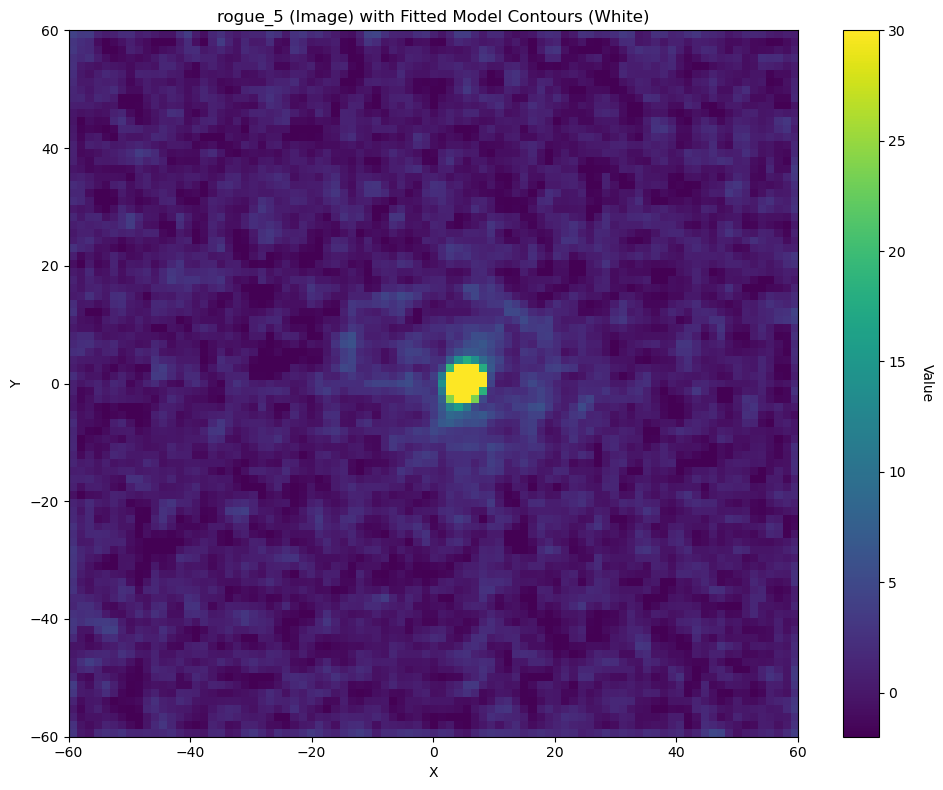

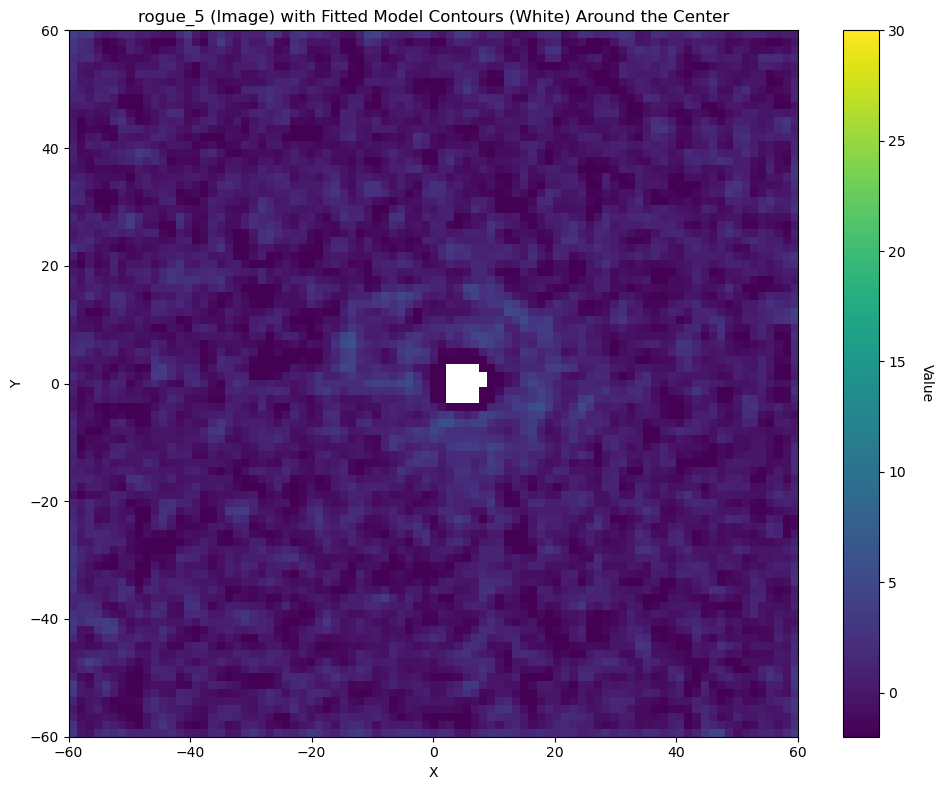

File name: mf_rogue_5_d=17.0_a=222.5_pix=8000.fits
Fitted Parameters:
A  = 1097.5197
h = 1.0021
q = 1.1214
x_offset = 5.0041
y_offset = 0.2793
theta = 999660.1891
C  = 0.1222


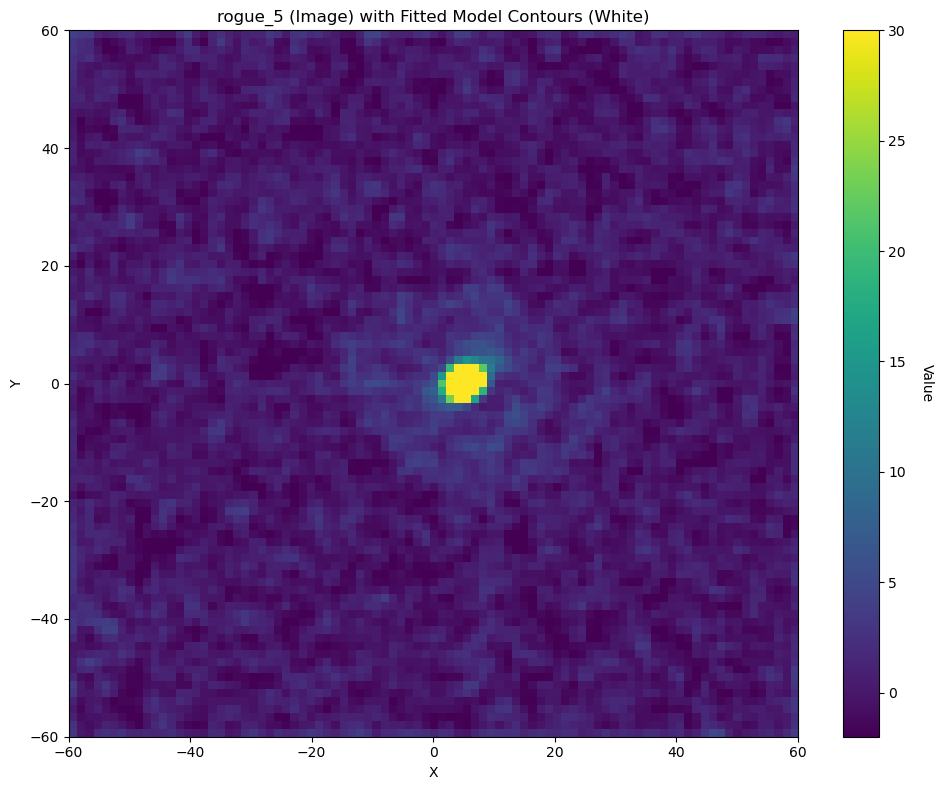

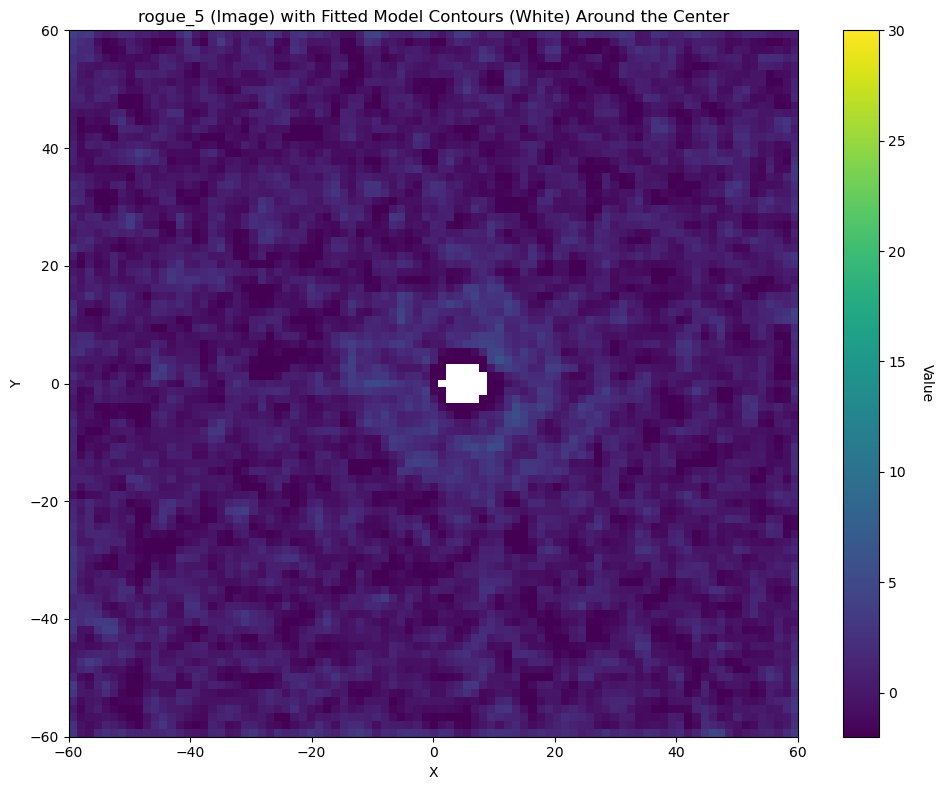

File name: mf_rogue_5_d=24.1_a=85.0_pix=8000.fits
Fitted Parameters:
A  = 1145.2013
h = 1.0890
q = 0.9362
x_offset = 4.8145
y_offset = 0.2189
theta = -3824691.7556
C  = 0.1158


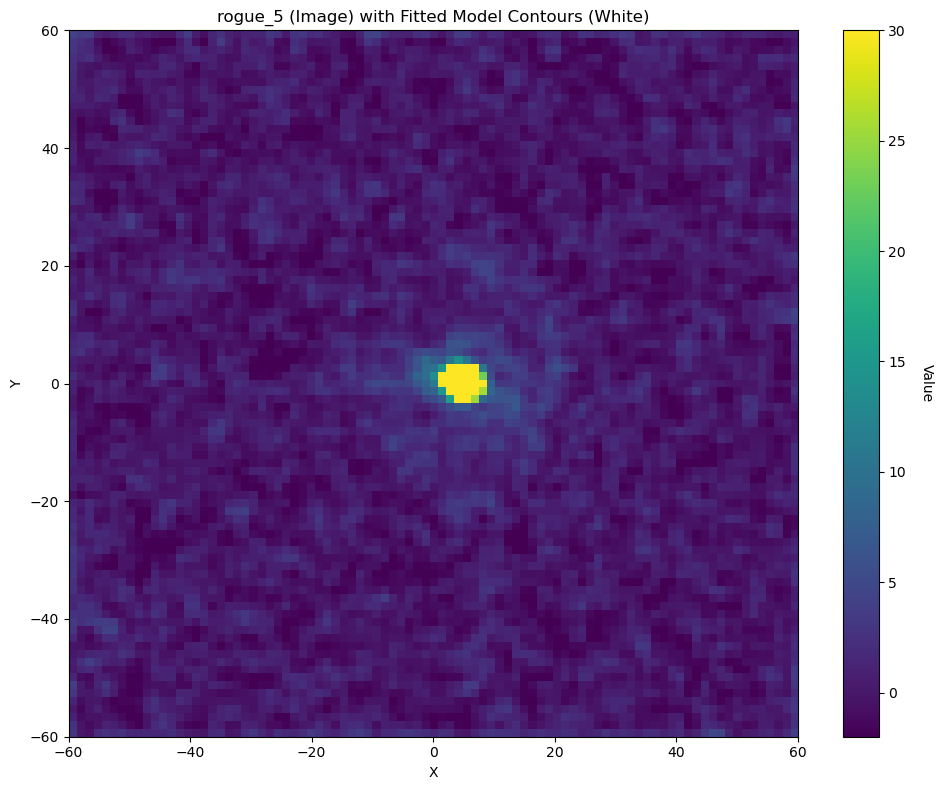

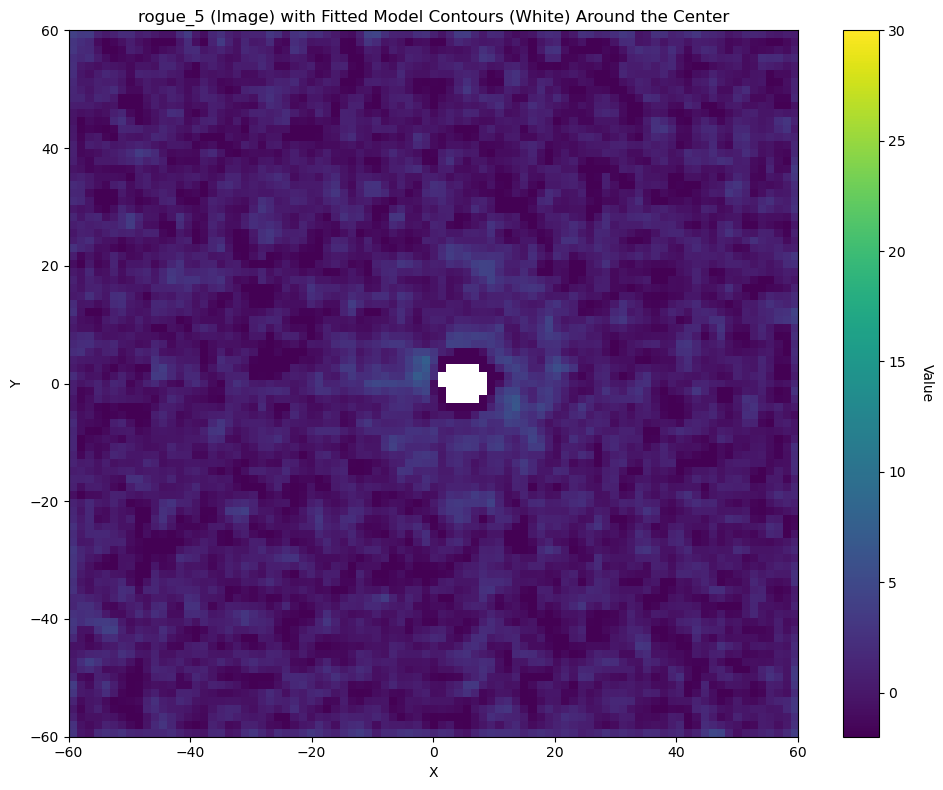

File name: mf_rogue_5_d=29.6_a=307.5_pix=8000.fits
Fitted Parameters:
A  = 1194.5595
h = 1.0710
q = 0.9235
x_offset = 4.8908
y_offset = 0.1761
theta = -2659538.4937
C  = 0.1419


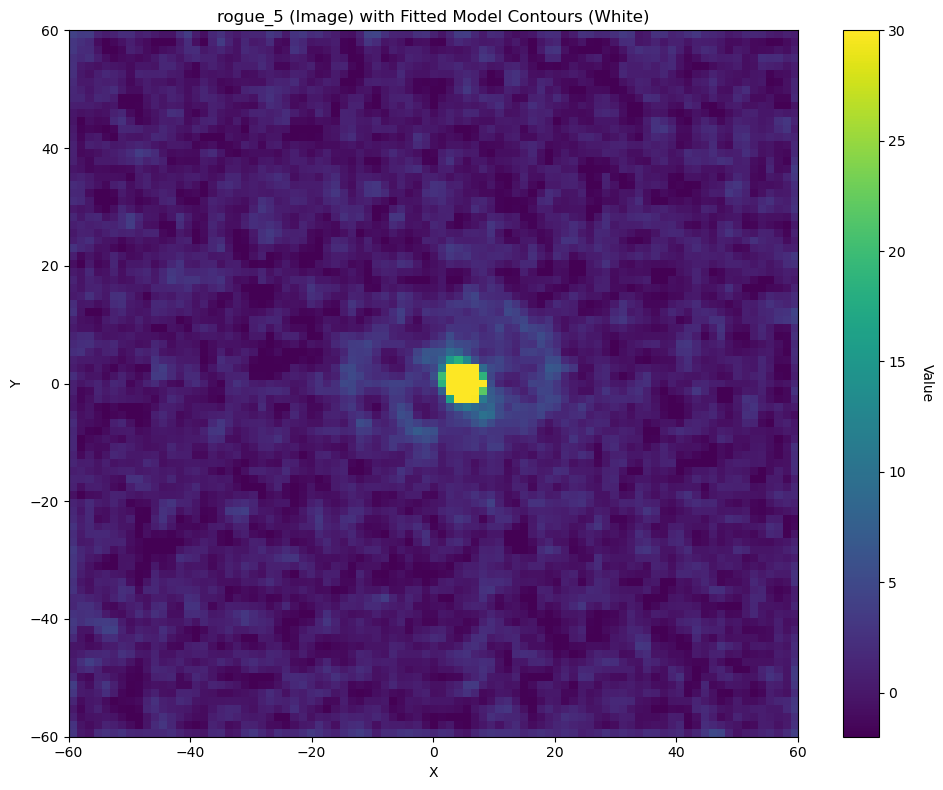

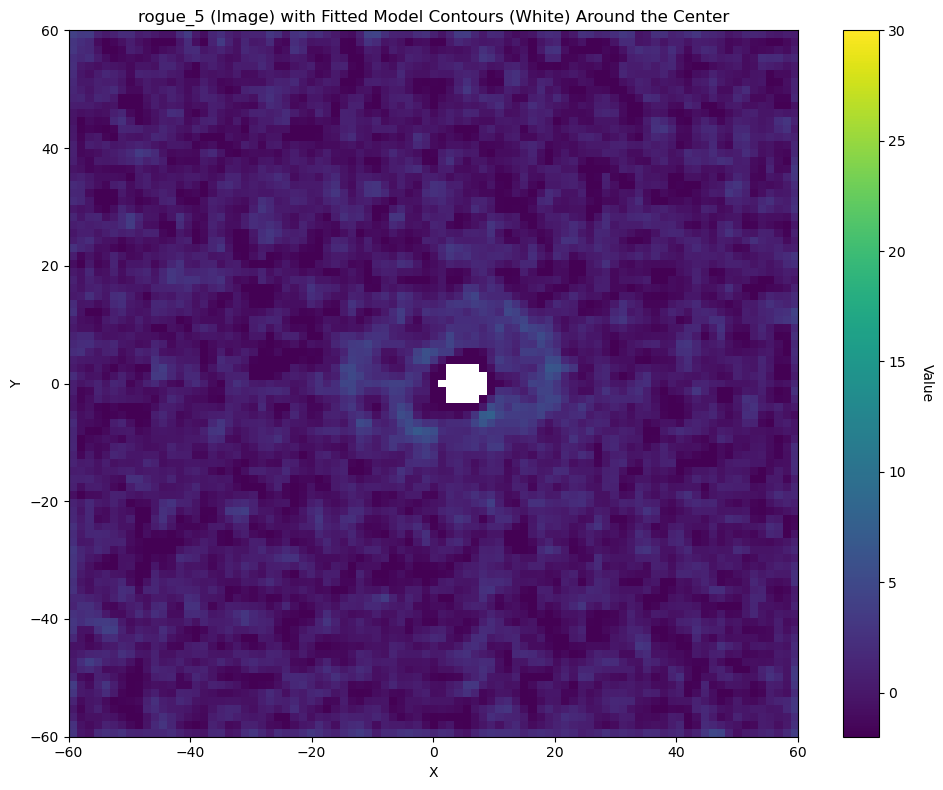

File name: mf_rogue_5_d=34.3_a=170.0_pix=8000.fits
Fitted Parameters:
A  = 1195.9701
h = 0.9713
q = 1.1178
x_offset = 4.7802
y_offset = 0.2578
theta = 341424.8827
C  = 0.1400


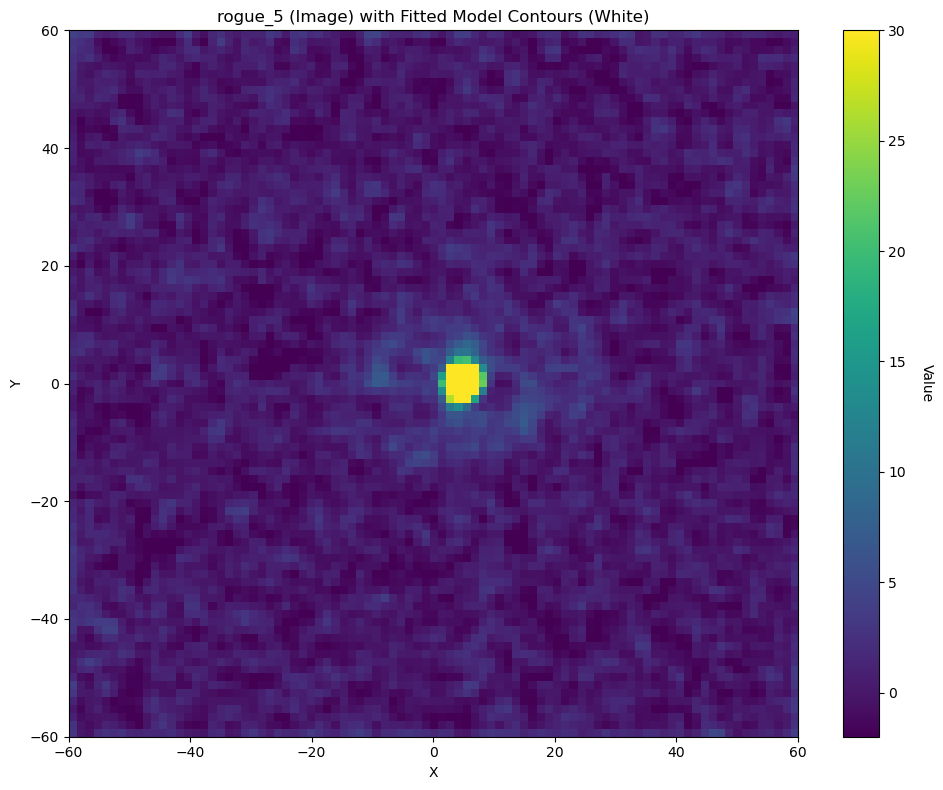

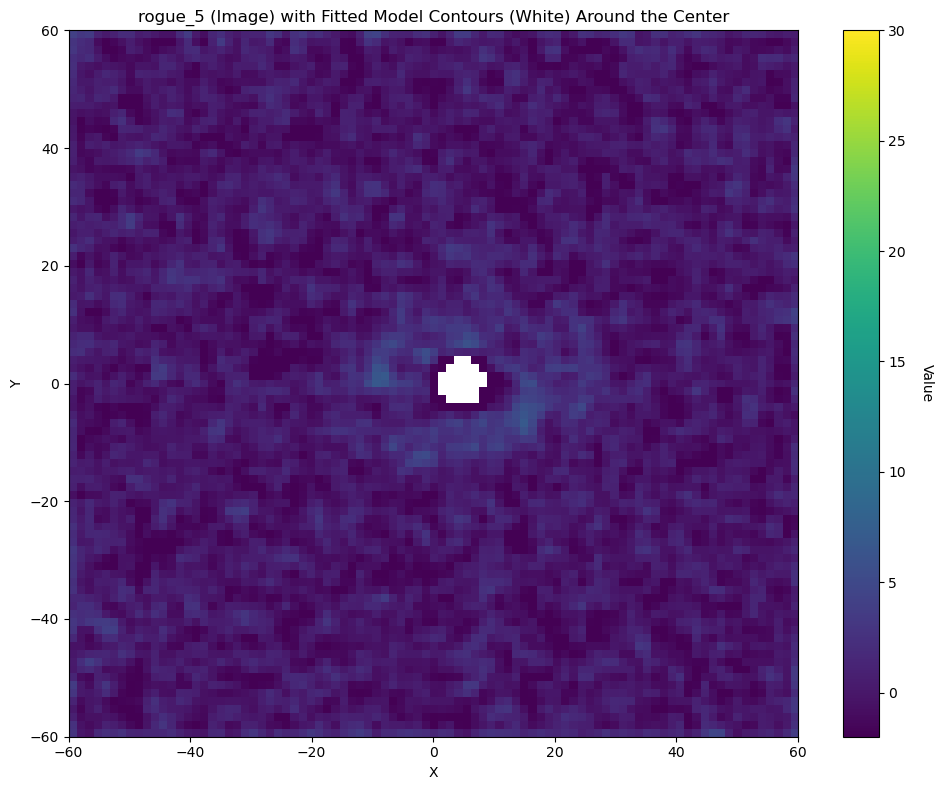

File name: mf_rogue_5_d=38.5_a=32.5_pix=8000.fits
Fitted Parameters:
A  = 1173.8930
h = 1.0185
q = 1.0576
x_offset = 4.6932
y_offset = 0.1667
theta = -1798607.1440
C  = 0.1209


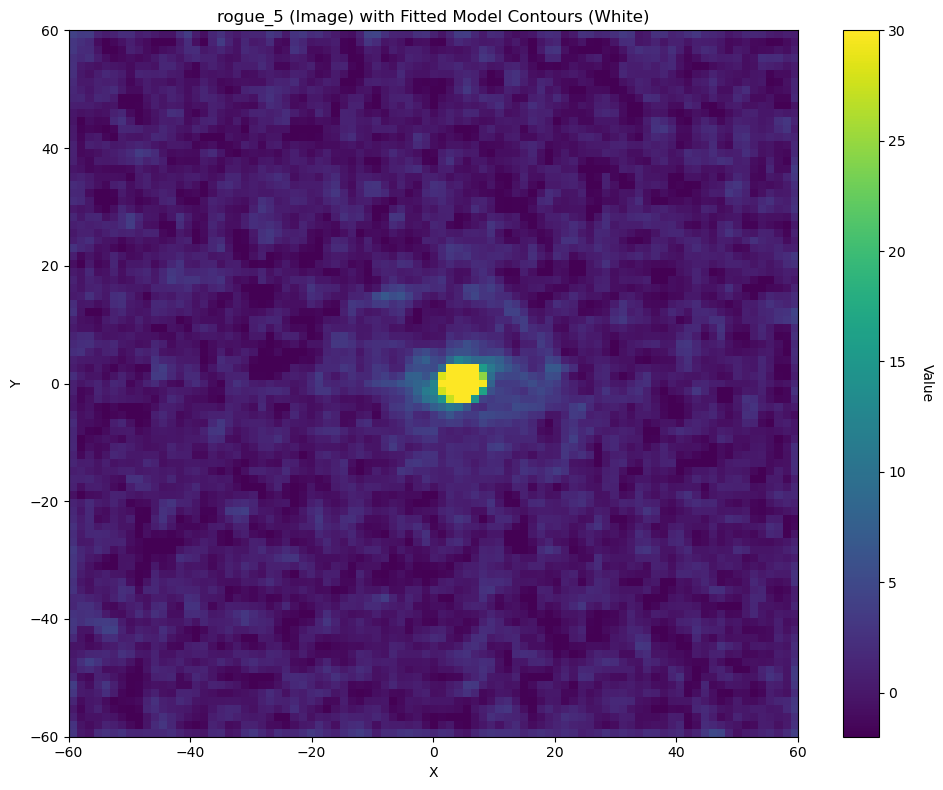

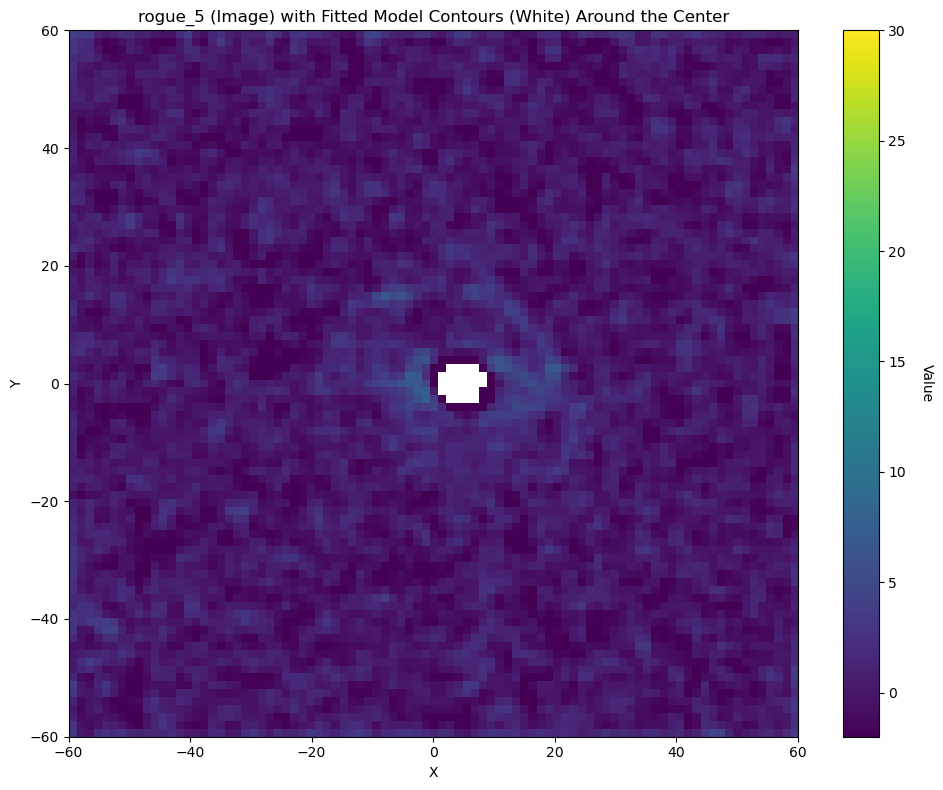

File name: mf_rogue_5_d=42.3_a=255.0_pix=8000.fits
Fitted Parameters:
A  = 1177.2464
h = 0.9841
q = 1.0965
x_offset = 4.7413
y_offset = 0.2239
theta = -3453504.1853
C  = 0.1672


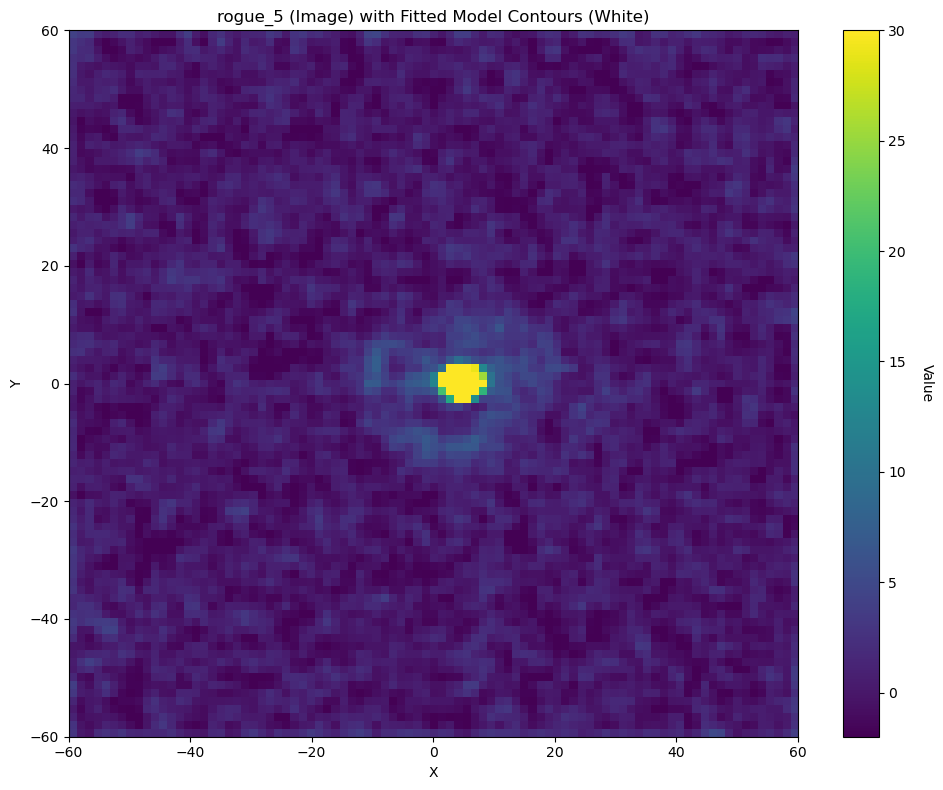

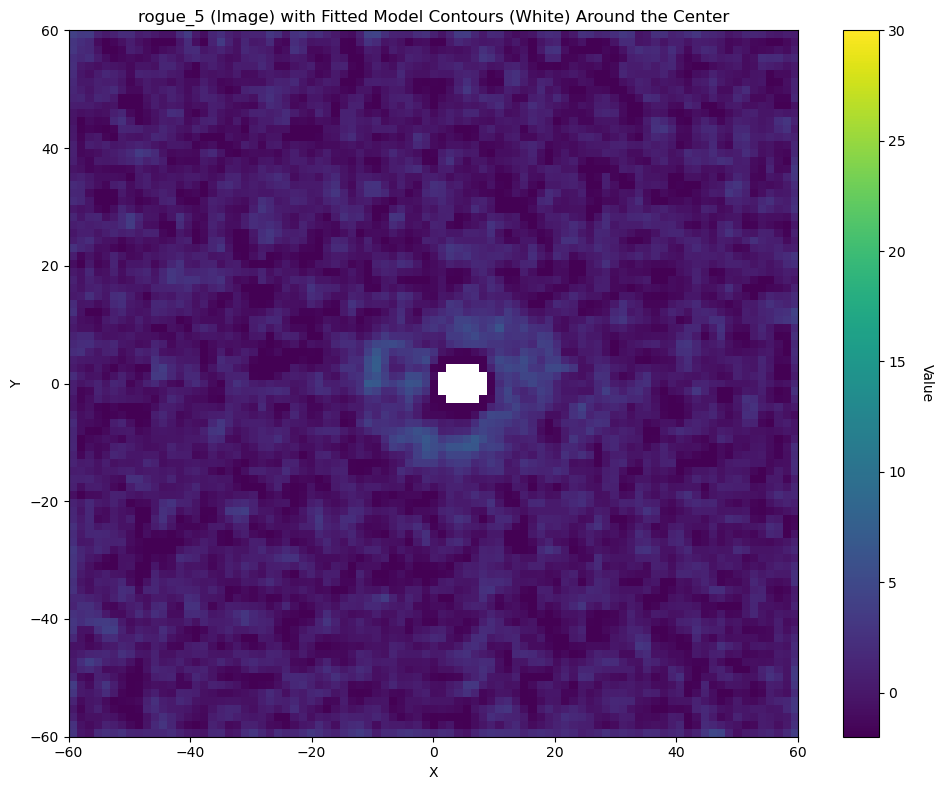

File name: mf_rogue_5_d=45.9_a=117.4_pix=8000.fits
Fitted Parameters:
A  = 1138.5413
h = 1.0140
q = 1.0882
x_offset = 4.5410
y_offset = 0.2470
theta = -5107431.0199
C  = 0.1336


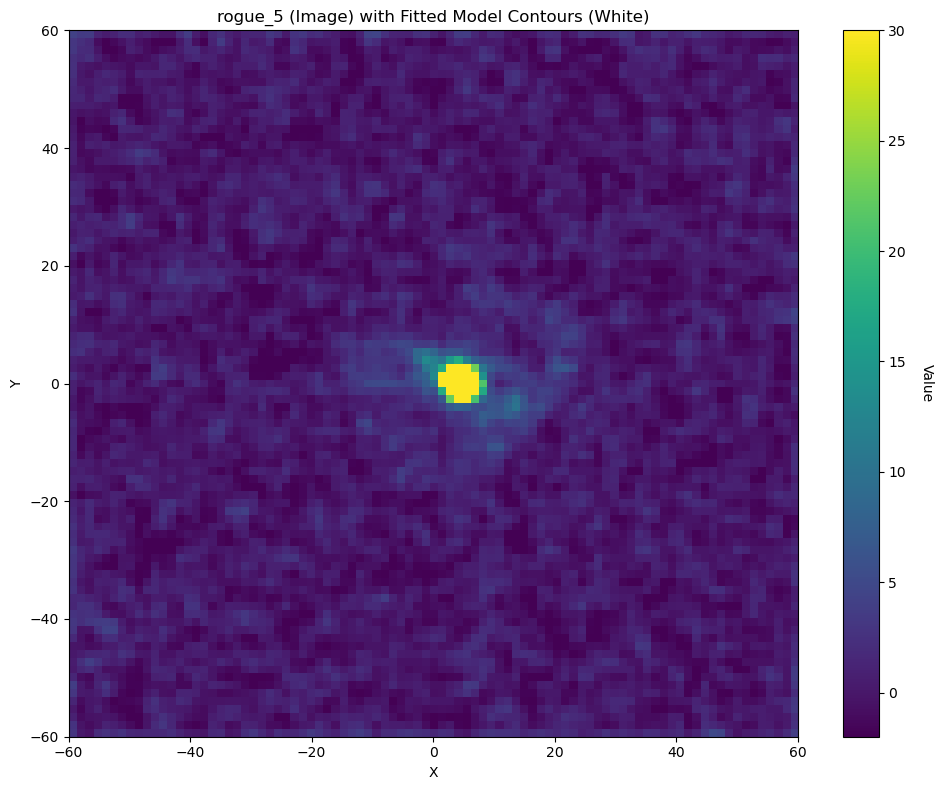

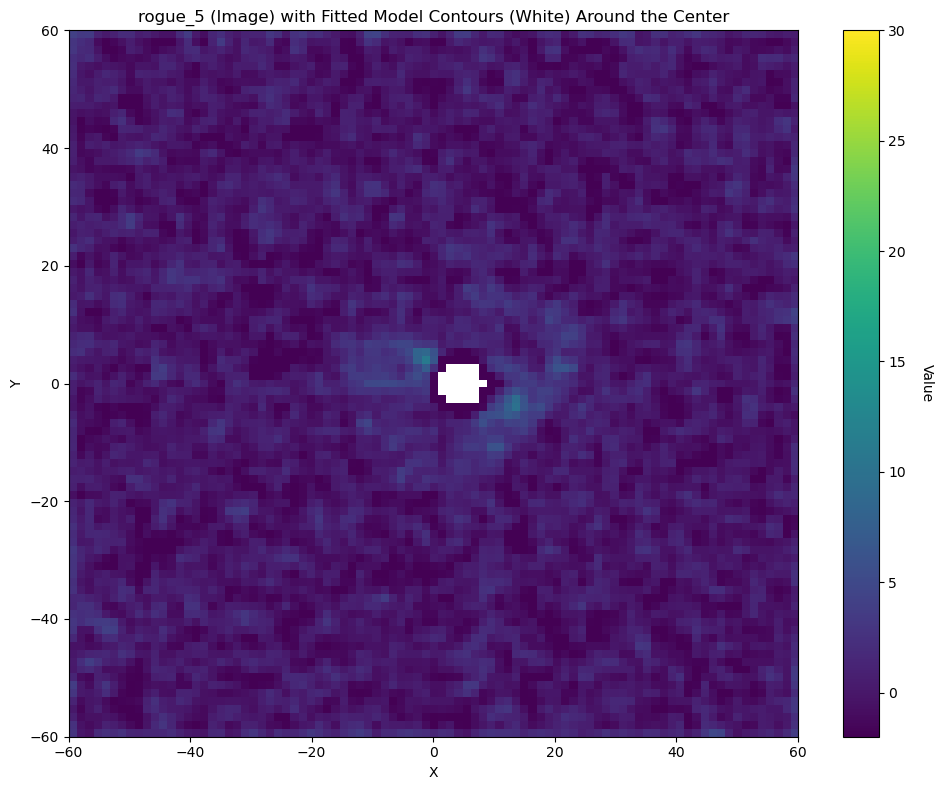

File name: mf_rogue_5_d=49.3_a=339.9_pix=8000.fits
Fitted Parameters:
A  = 1219.7568
h = 1.0205
q = 1.0337
x_offset = 4.6064
y_offset = 0.1648
theta = -2952276.8012
C  = 0.1336


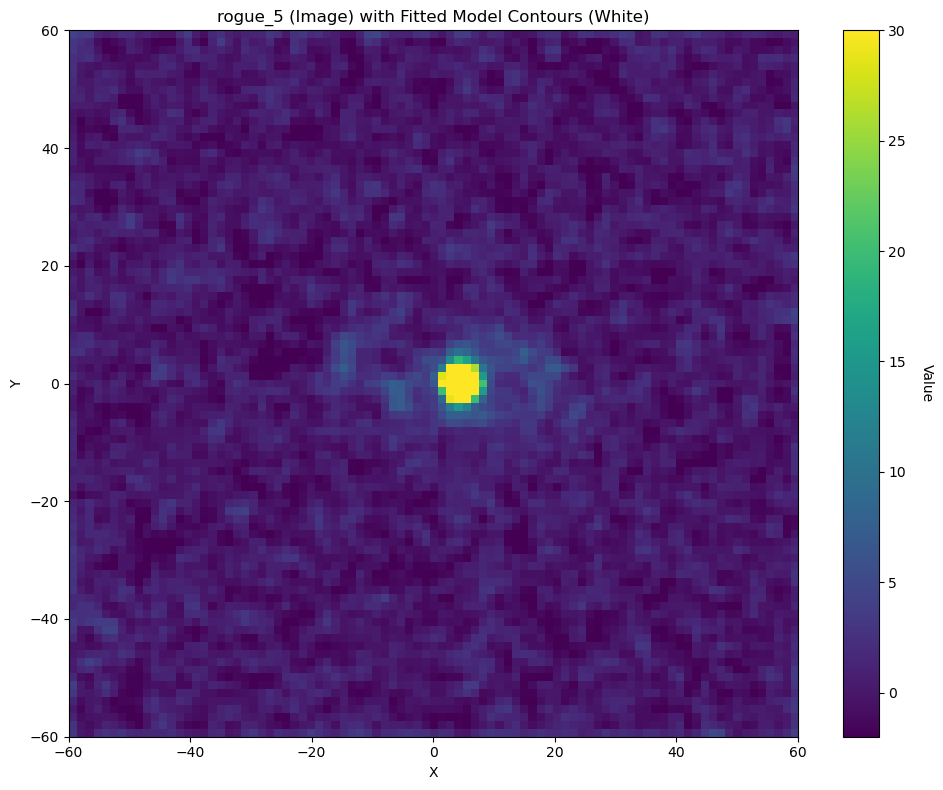

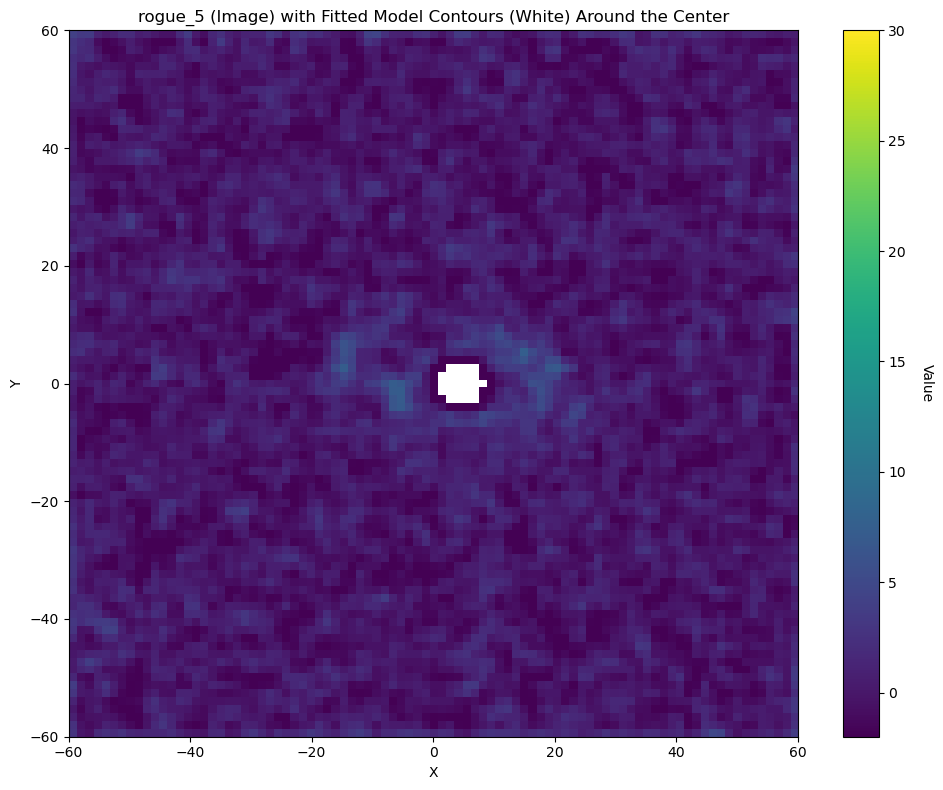

File name: mf_rogue_5_d=52.5_a=202.4_pix=8000.fits
Fitted Parameters:
A  = 1168.8818
h = 1.0775
q = 0.9366
x_offset = 4.5746
y_offset = 0.2672
theta = -1141990.2530
C  = 0.1597


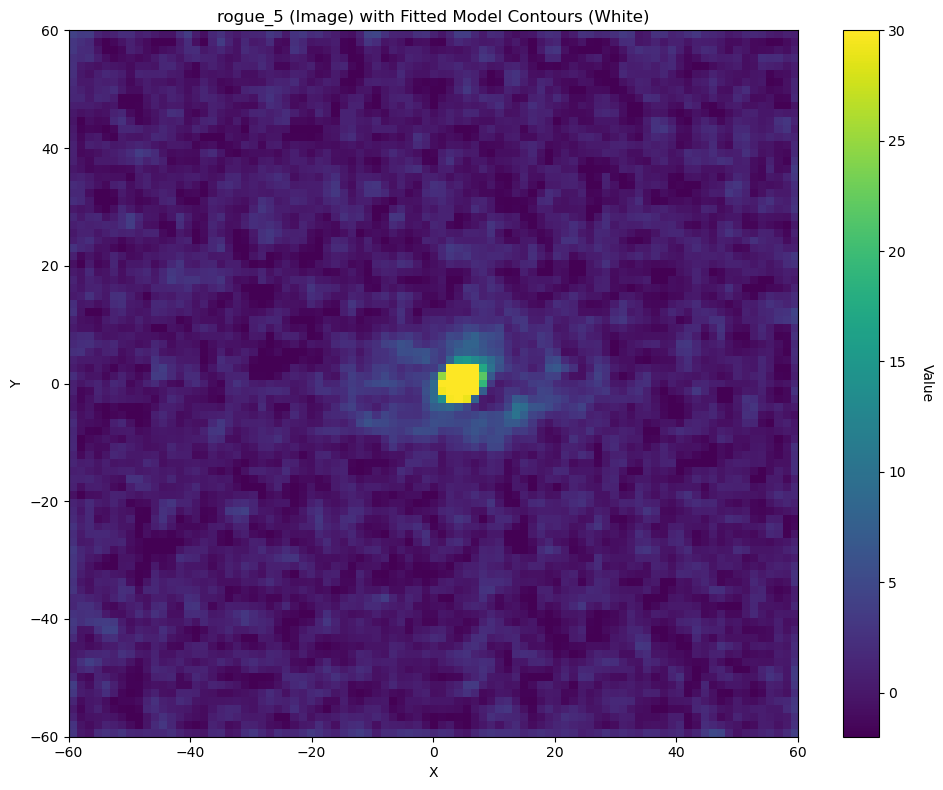

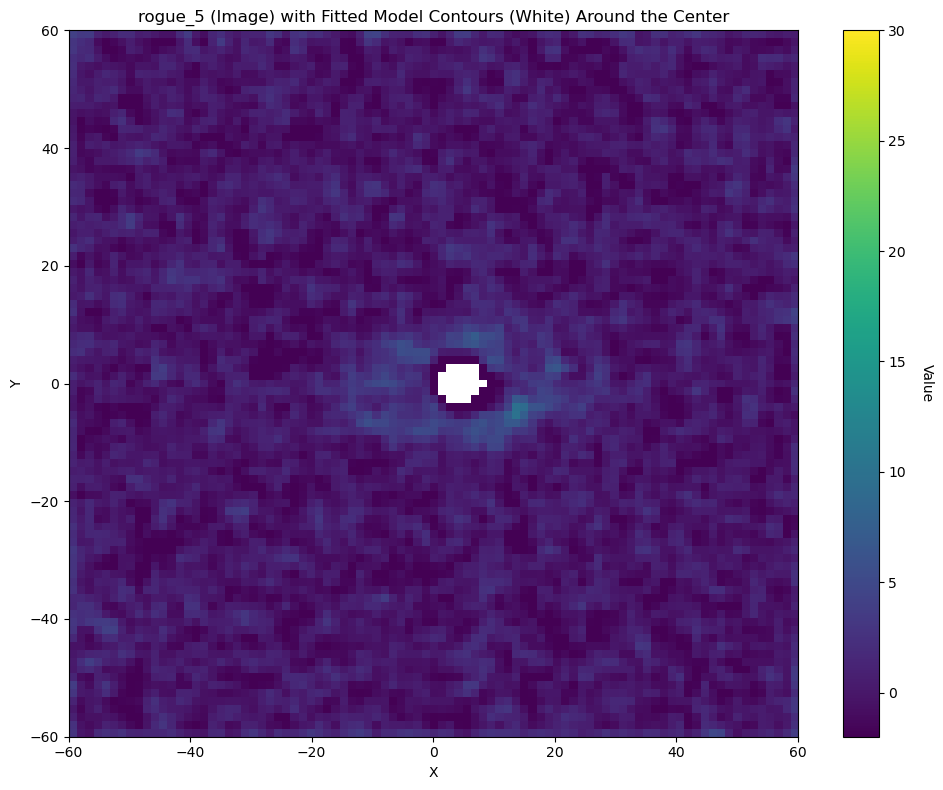

File name: mf_rogue_5_d=55.6_a=64.9_pix=8000.fits
Fitted Parameters:
A  = 1063.3921
h = 1.2101
q = 0.8512
x_offset = 4.3669
y_offset = 0.2652
theta = -5847610.0459
C  = 0.0947


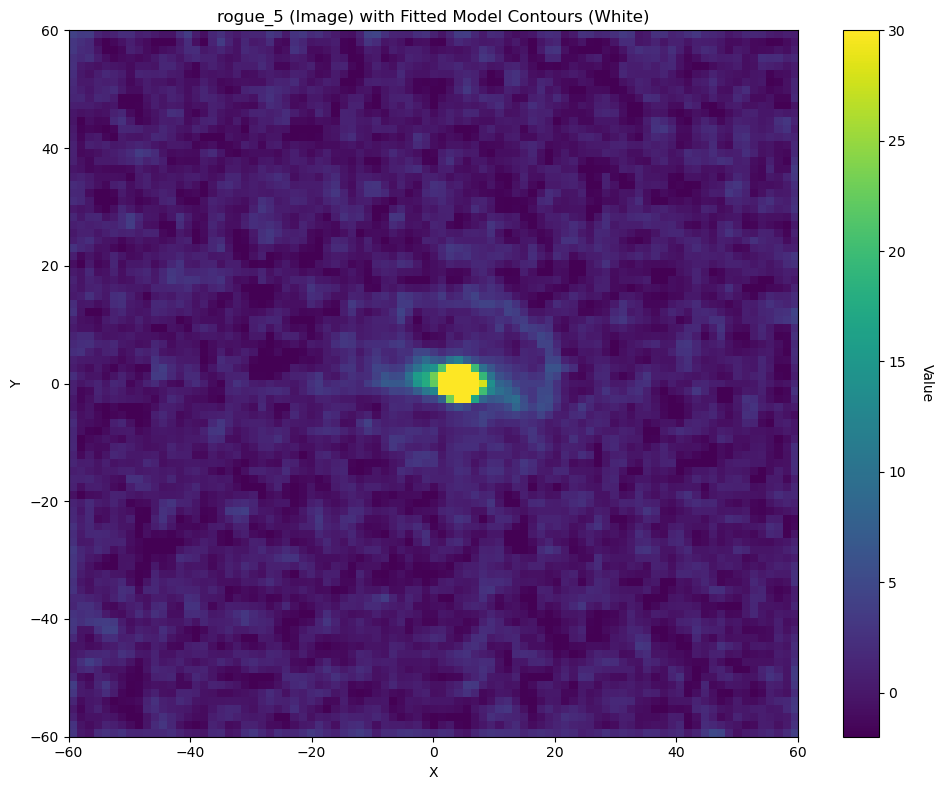

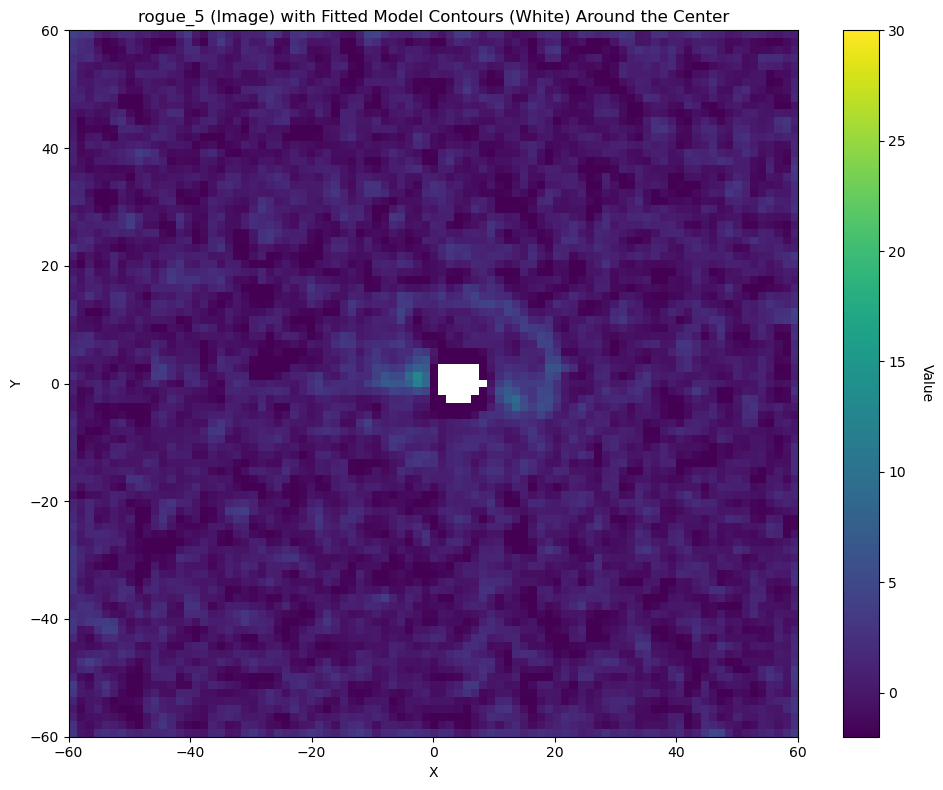

File name: mf_rogue_5_d=58.6_a=287.4_pix=8000.fits
Fitted Parameters:
A  = 1146.9195
h = 0.9925
q = 1.1567
x_offset = 4.4171
y_offset = 0.2455
theta = -6414380.1365
C  = 0.1460


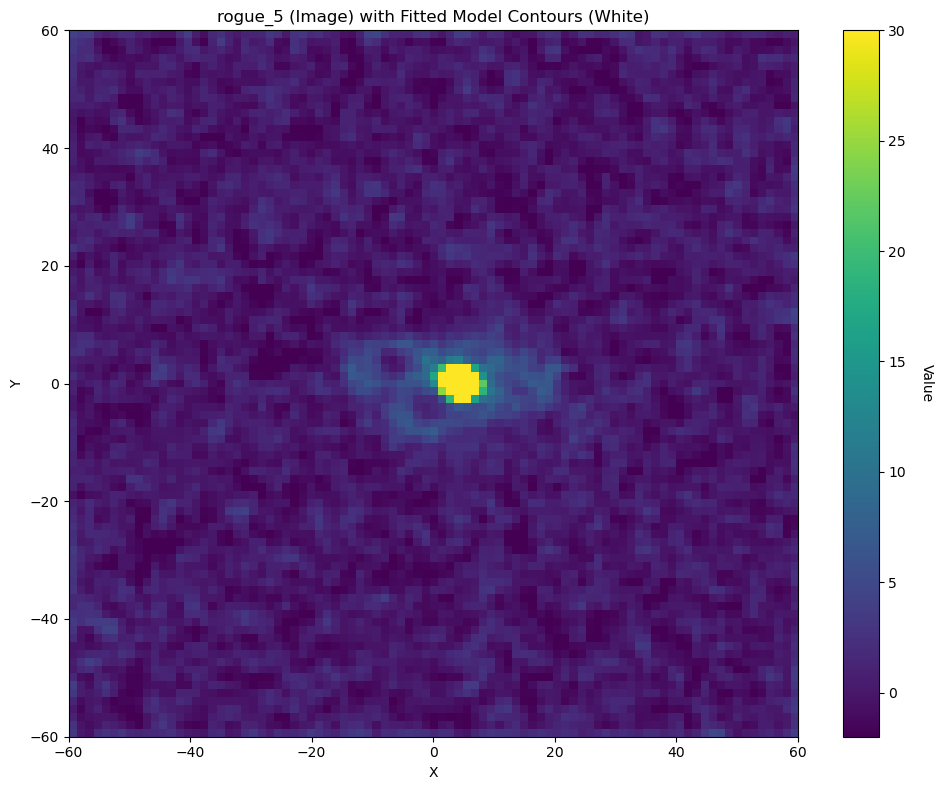

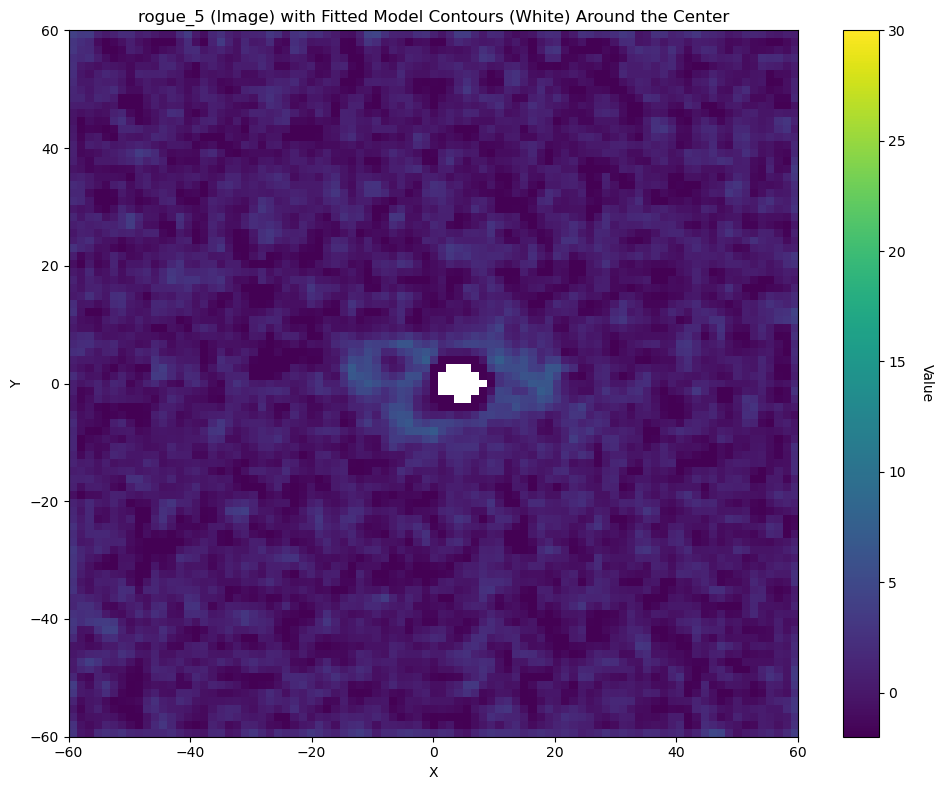

File name: mf_rogue_5_d=61.4_a=149.9_pix=8000.fits
Fitted Parameters:
A  = 1108.9313
h = 1.0979
q = 0.9755
x_offset = 4.3312
y_offset = 0.3050
theta = -4376581.8585
C  = 0.1349


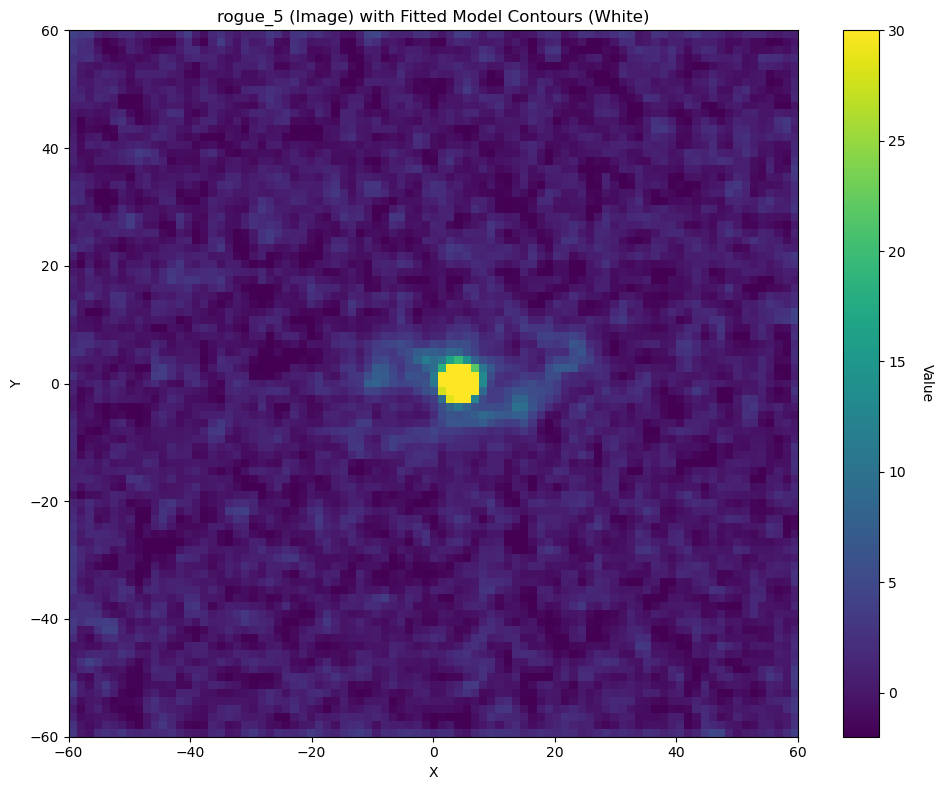

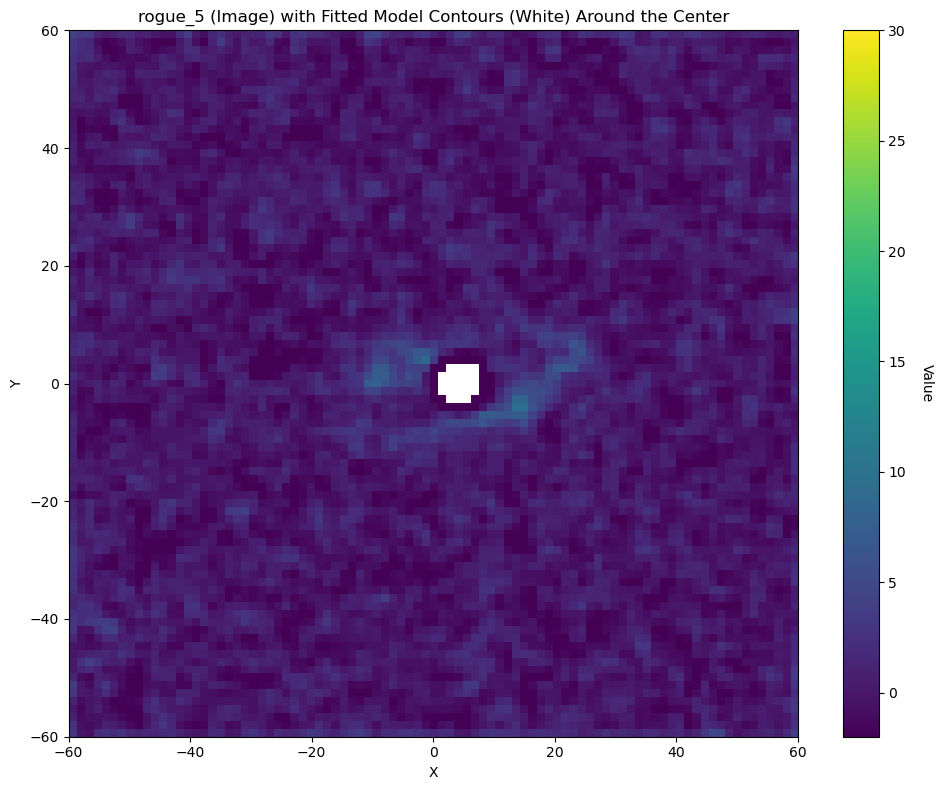

File name: mf_rogue_5_d=64.2_a=12.4_pix=8000.fits
Fitted Parameters:
A  = 1110.6846
h = 1.0249
q = 1.1526
x_offset = 4.3060
y_offset = 0.2698
theta = -4402230.5898
C  = 0.1119


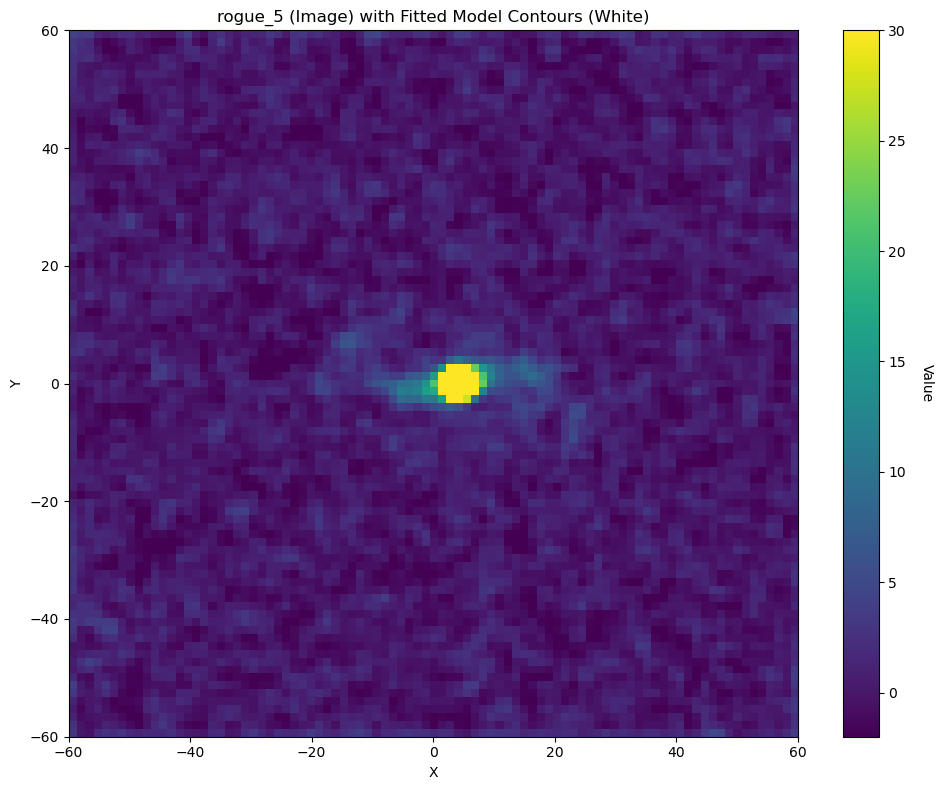

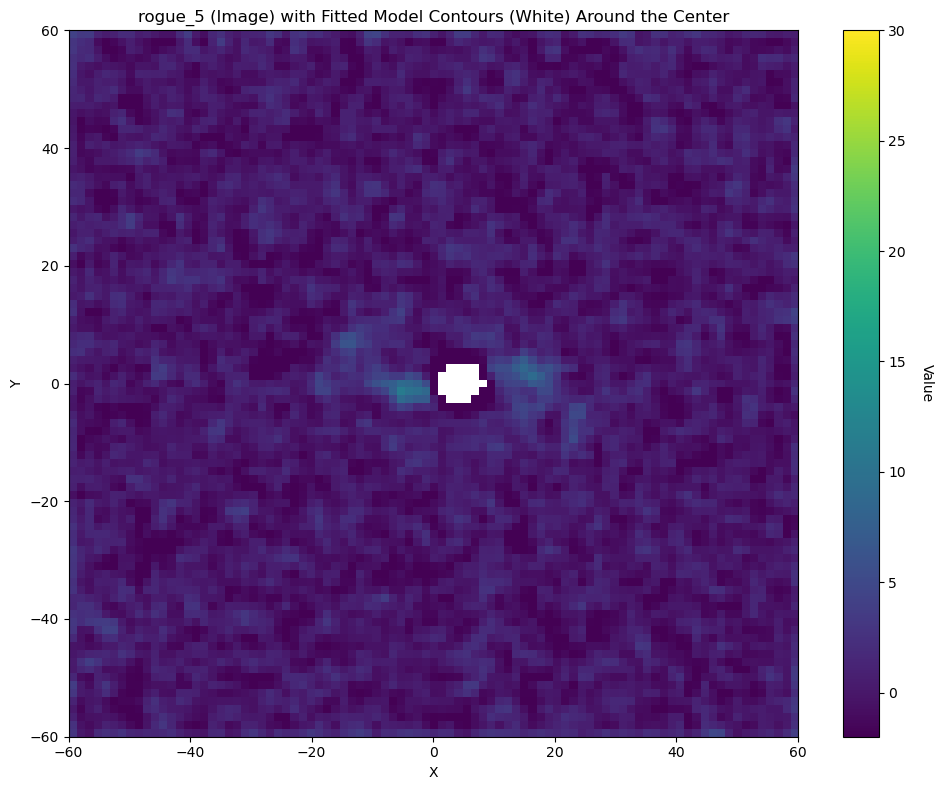

File name: mf_rogue_5_d=67.0_a=234.9_pix=8000.fits
Fitted Parameters:
A  = 1067.3659
h = 1.0040
q = 1.2243
x_offset = 4.2338
y_offset = 0.3121
theta = -3533400.9997
C  = 0.1466


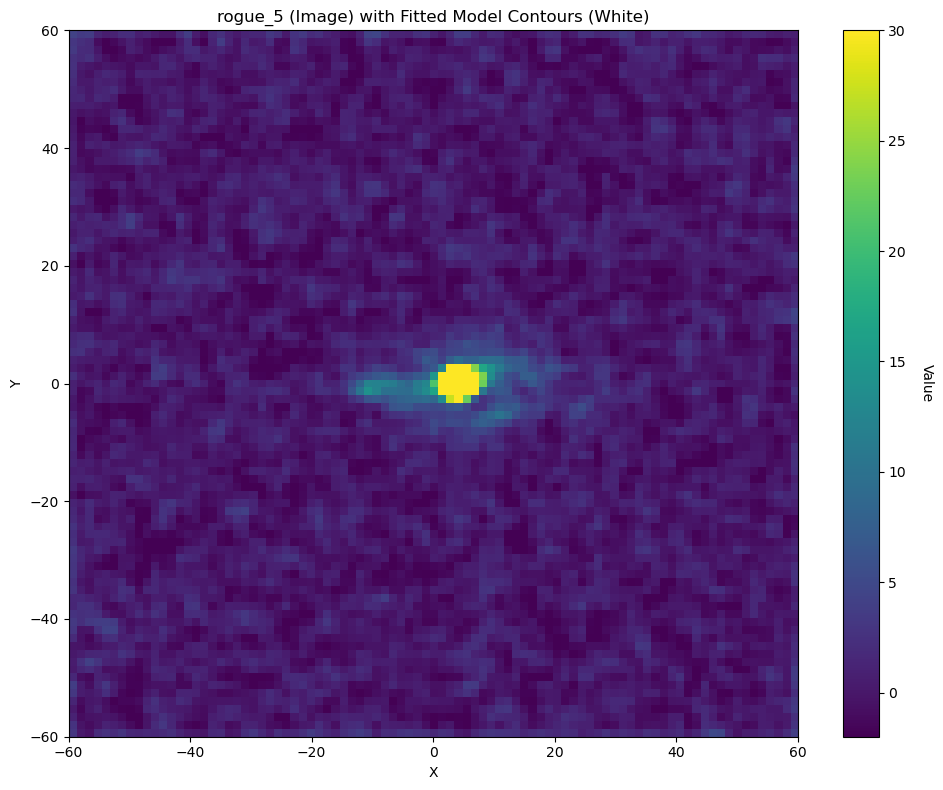

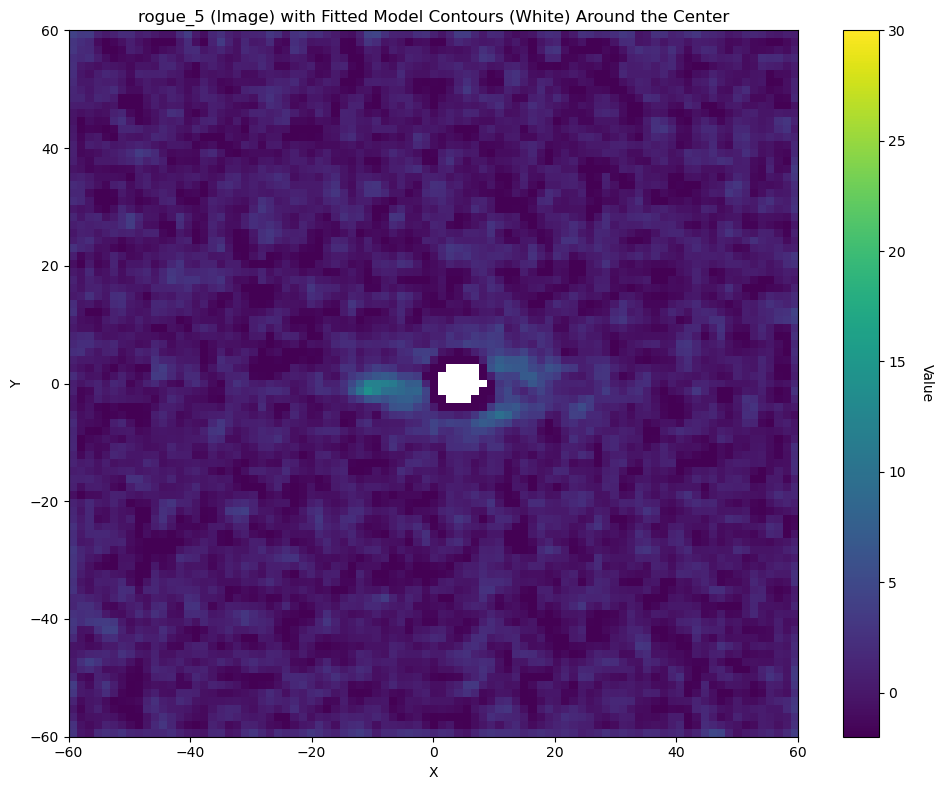

File name: mf_rogue_5_d=69.6_a=97.4_pix=8000.fits
Fitted Parameters:
A  = 1084.6099
h = 1.0181
q = 1.1989
x_offset = 3.9659
y_offset = 0.3185
theta = -7773037.1493
C  = 0.1156


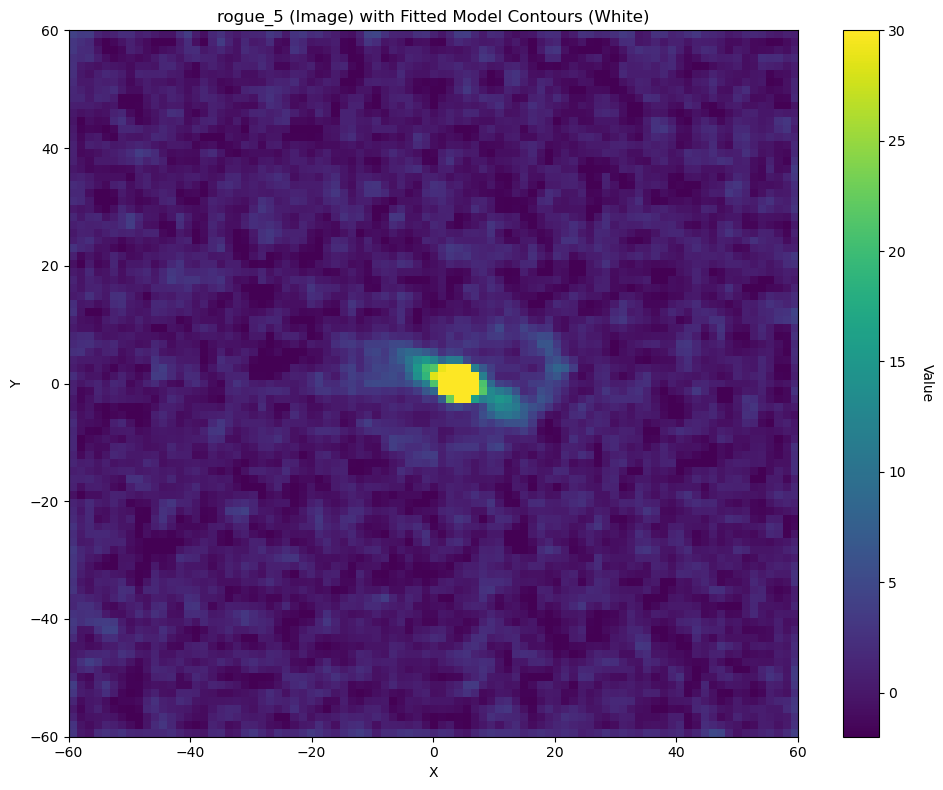

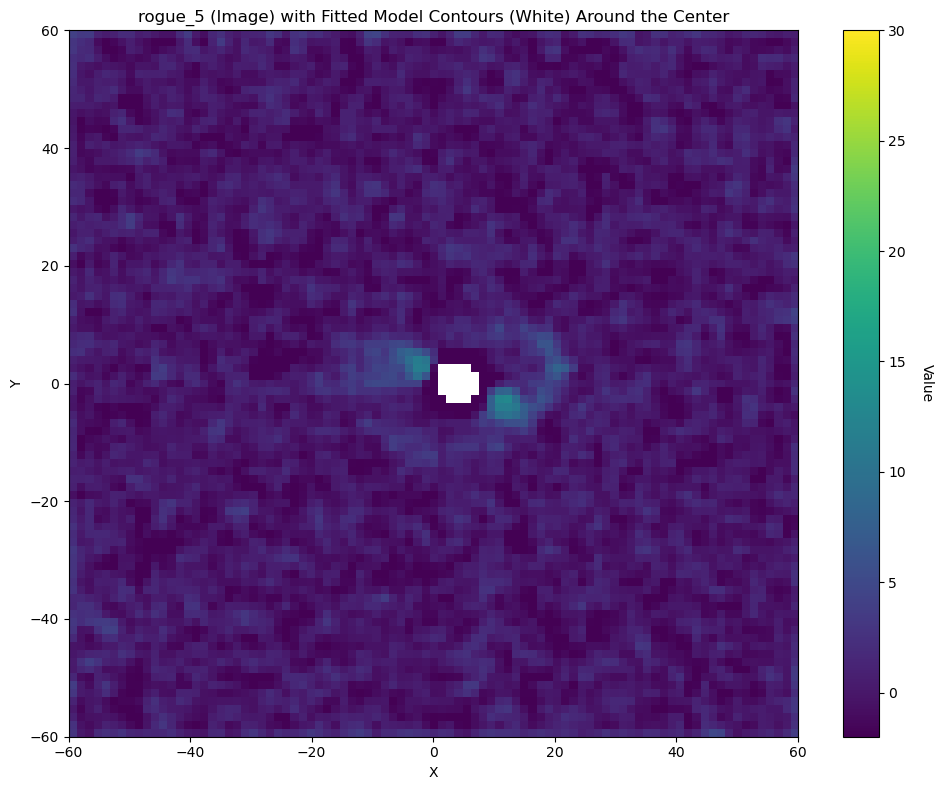

File name: mf_rogue_5_d=72.3_a=319.9_pix=8000.fits
Fitted Parameters:
A  = 1159.3363
h = 1.0249
q = 1.1404
x_offset = 4.0347
y_offset = 0.3029
theta = -6616393.7689
C  = 0.1231


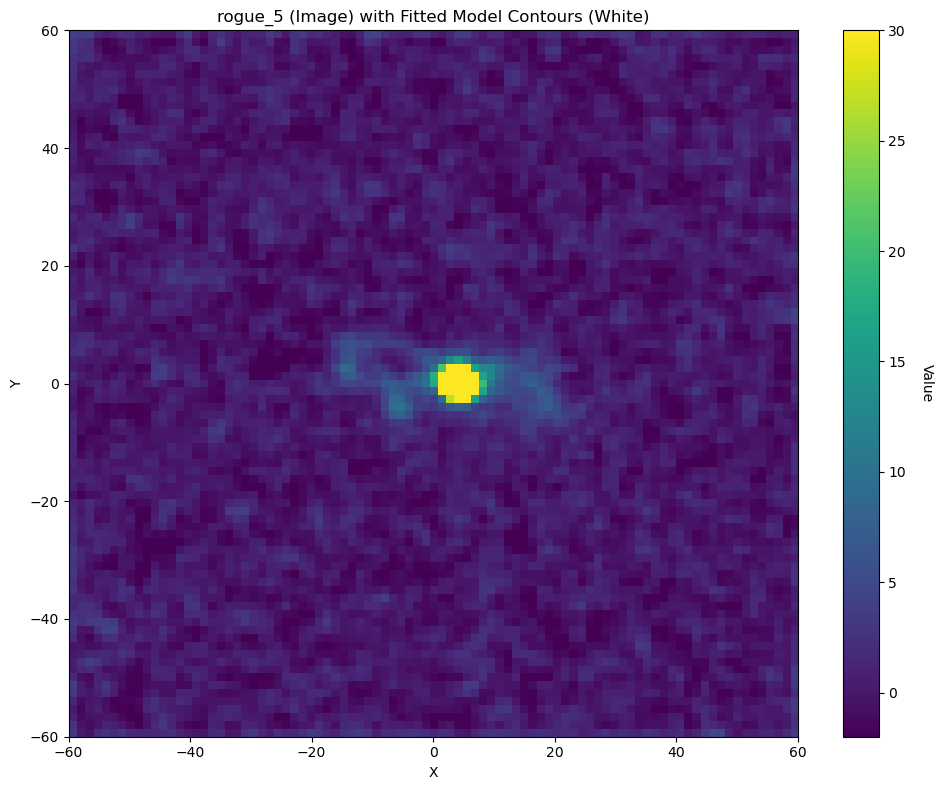

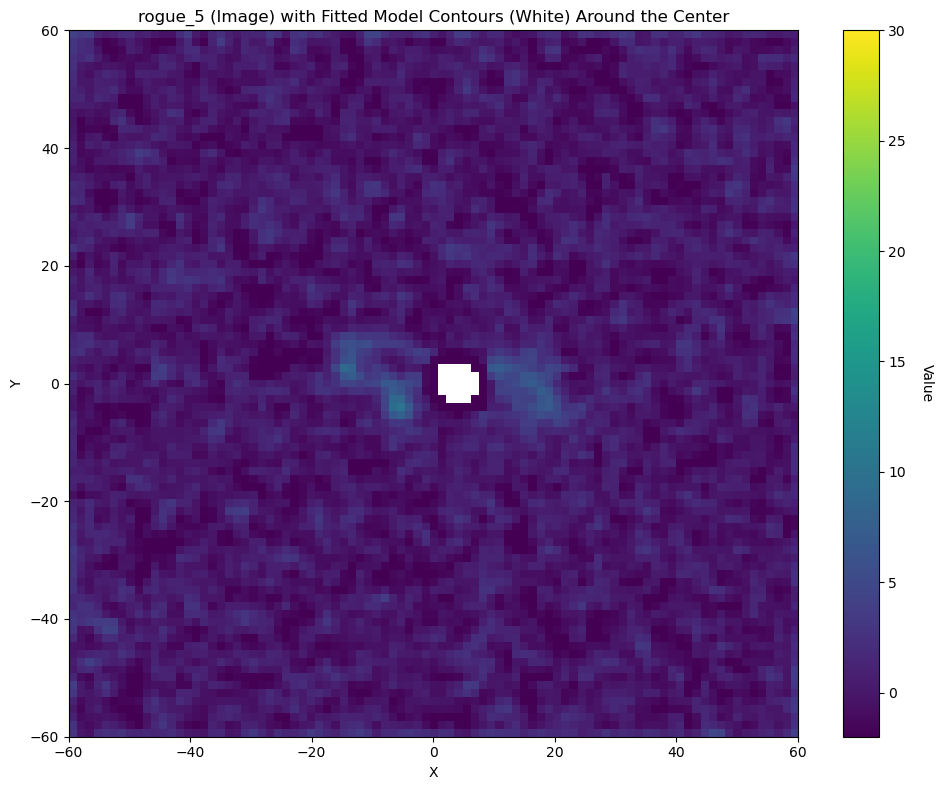

File name: mf_rogue_5_d=74.9_a=182.4_pix=8000.fits
Fitted Parameters:
A  = 1115.9266
h = 1.0320
q = 1.1434
x_offset = 4.0423
y_offset = 0.3213
theta = -3473195.2923
C  = 0.1359


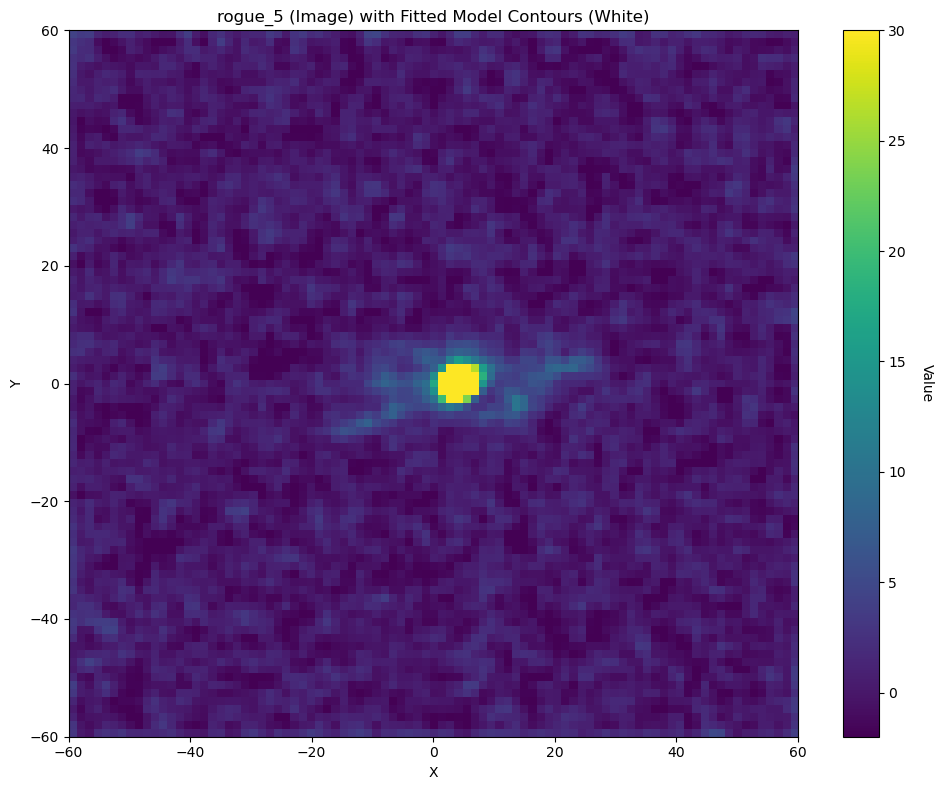

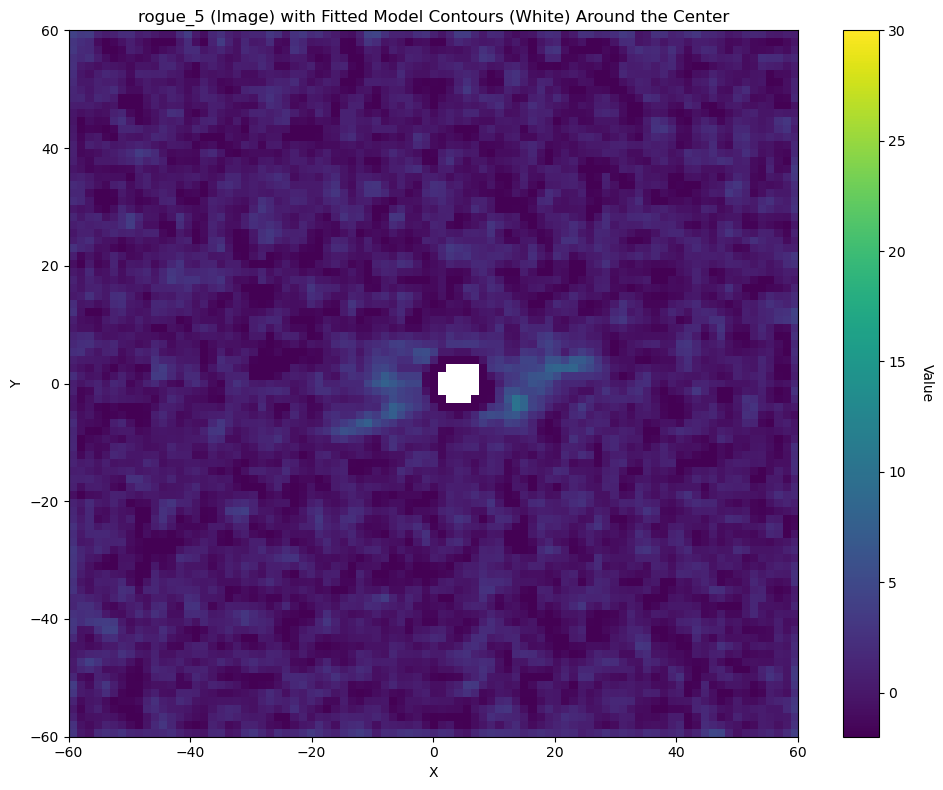

File name: mf_rogue_5_d=77.4_a=44.9_pix=8000.fits
Fitted Parameters:
A  = 1073.8540
h = 1.0123
q = 1.2426
x_offset = 3.9671
y_offset = 0.3013
theta = -6663665.2569
C  = 0.1125


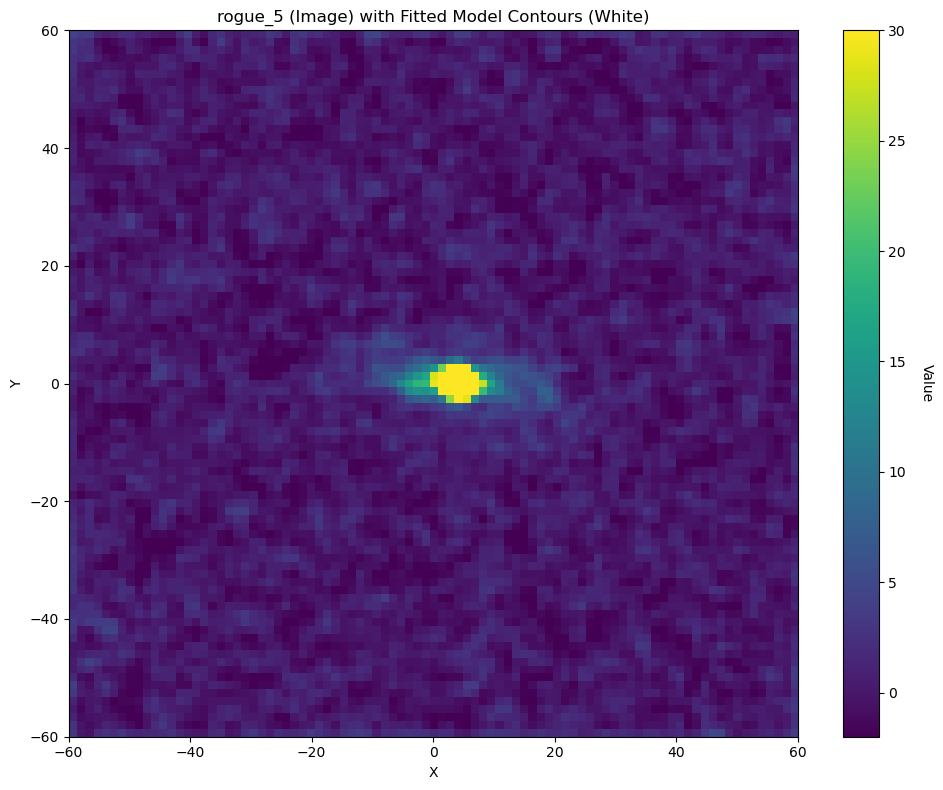

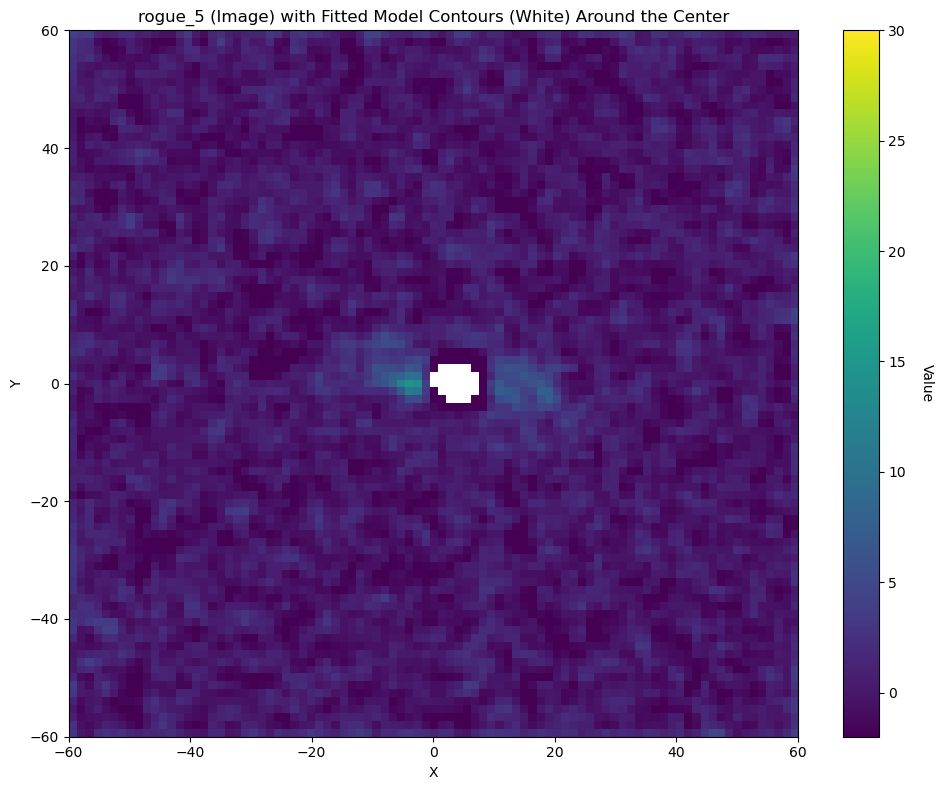

File name: mf_rogue_5_d=80.0_a=267.4_pix=8000.fits
Fitted Parameters:
A  = 1110.4281
h = 1.2192
q = 0.8229
x_offset = 3.8915
y_offset = 0.2688
theta = -5701101.5685
C  = 0.1554


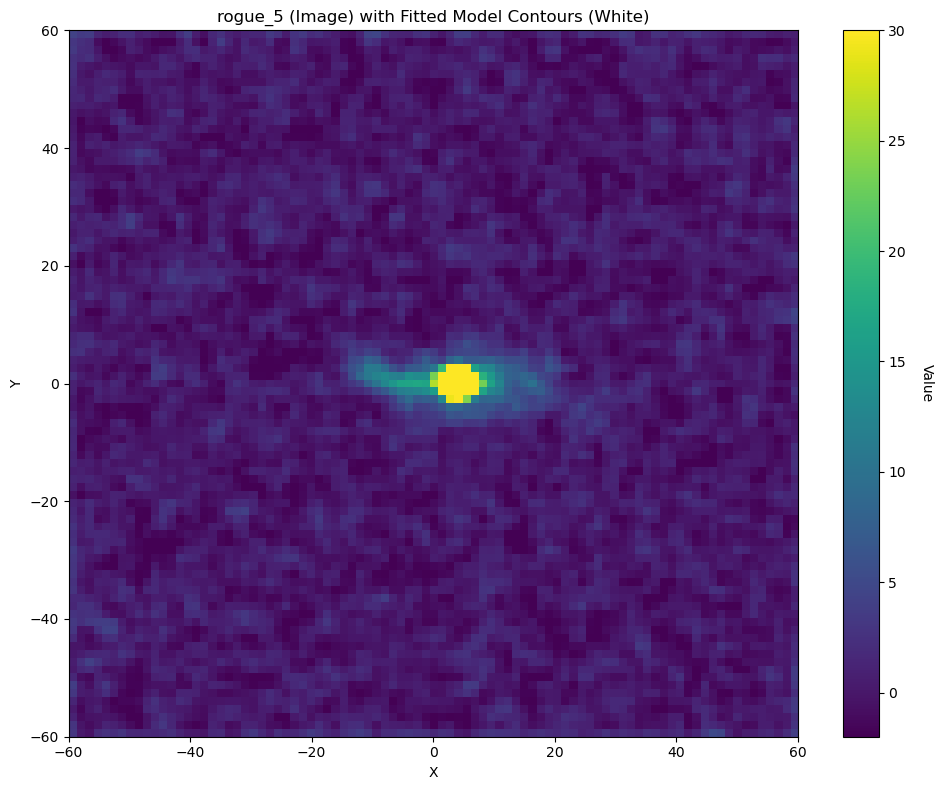

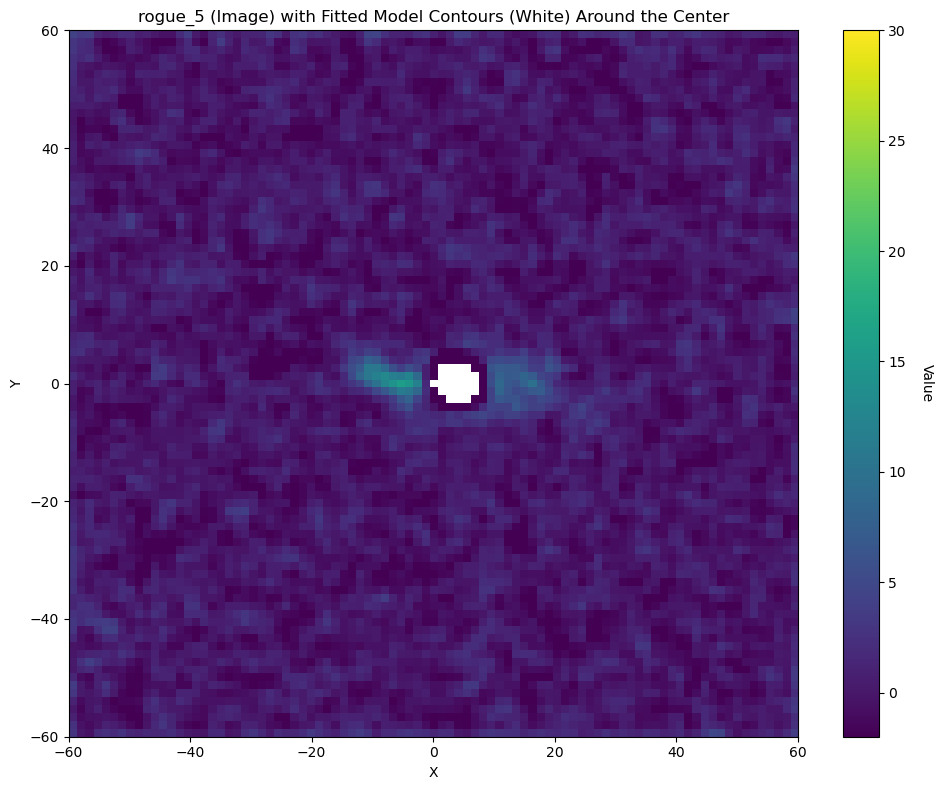

File name: mf_rogue_5_d=82.5_a=129.8_pix=8000.fits
Fitted Parameters:
A  = 1171.4181
h = 1.0193
q = 1.1170
x_offset = 3.7881
y_offset = 0.2695
theta = -6882599.6663
C  = 0.1275


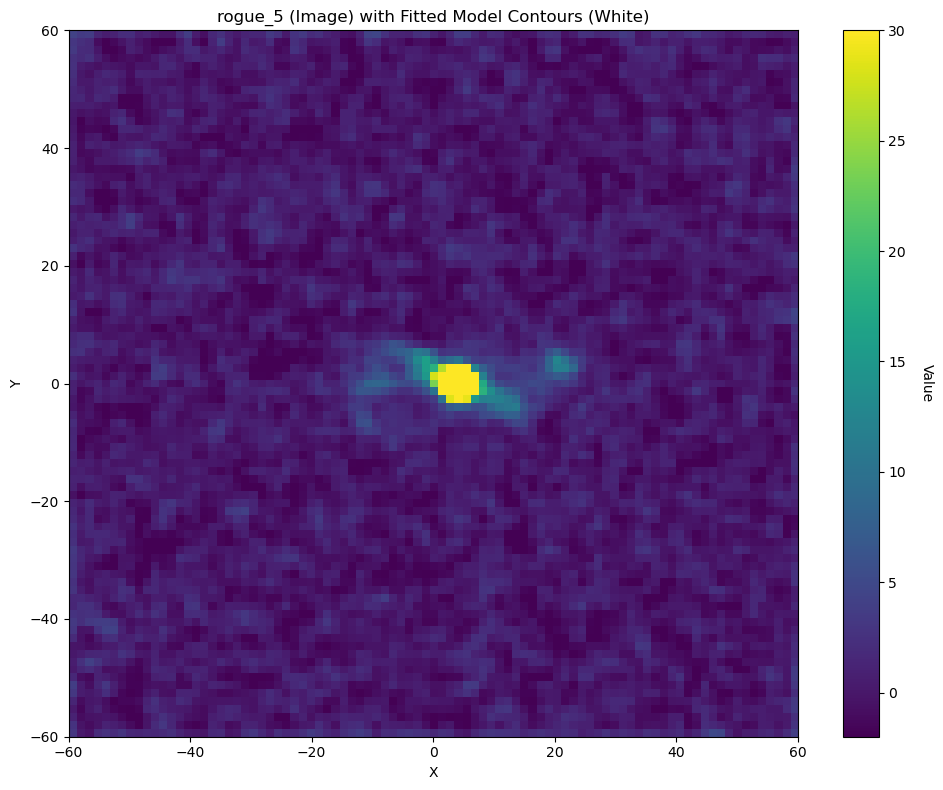

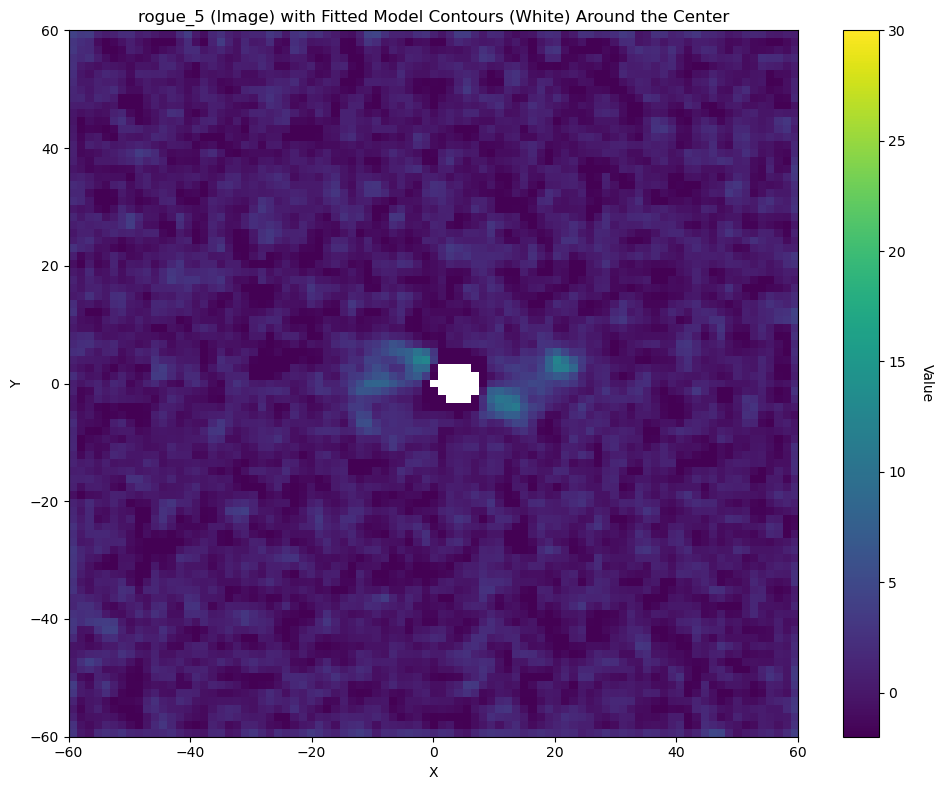

File name: mf_rogue_5_d=85.0_a=352.3_pix=8000.fits
Fitted Parameters:
A  = 1201.9023
h = 1.0053
q = 1.1448
x_offset = 3.8867
y_offset = 0.2926
theta = -7060498.6327
C  = 0.1315


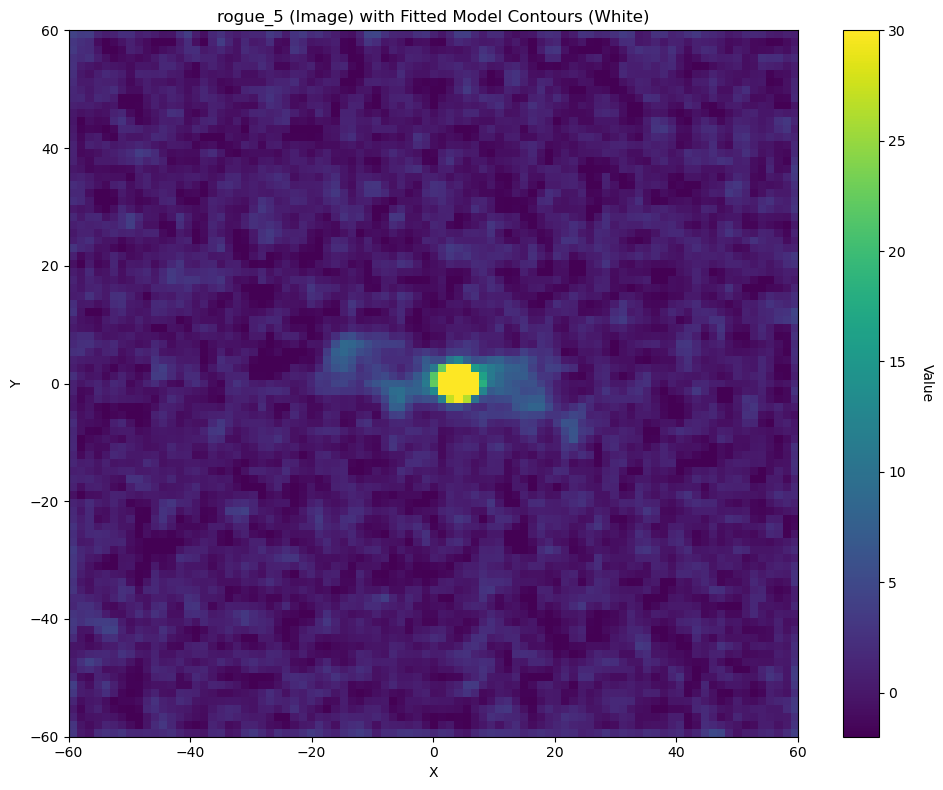

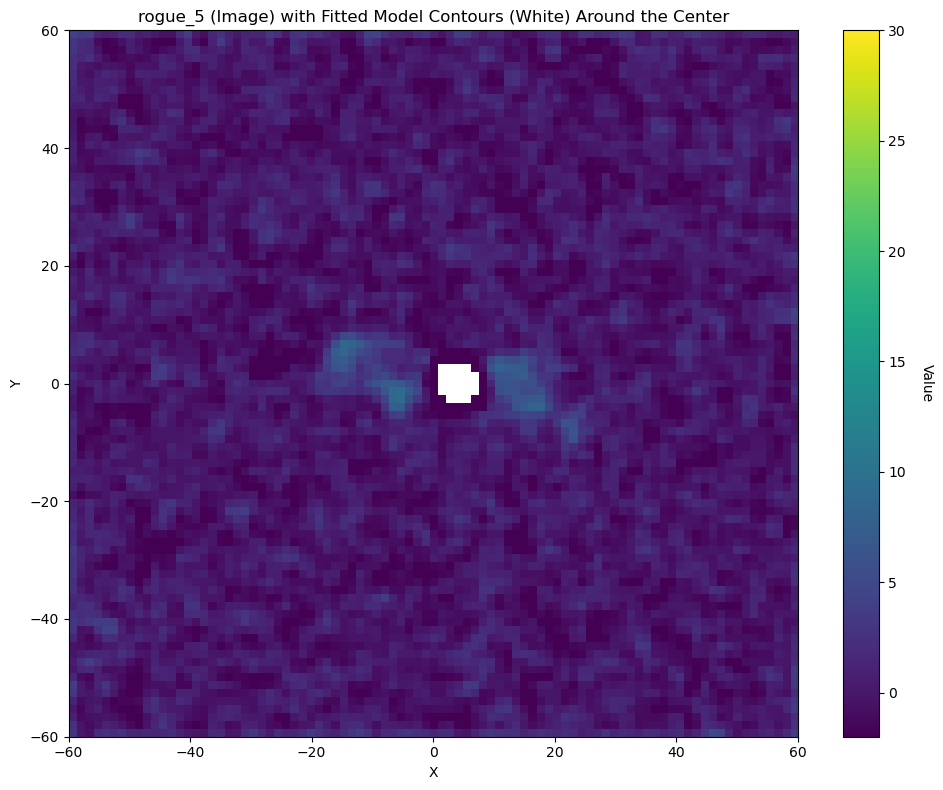

File name: mf_rogue_5_d=87.5_a=214.8_pix=8000.fits
Fitted Parameters:
A  = 1100.5132
h = 1.2396
q = 0.8050
x_offset = 3.9419
y_offset = 0.2937
theta = -4452400.0545
C  = 0.1342


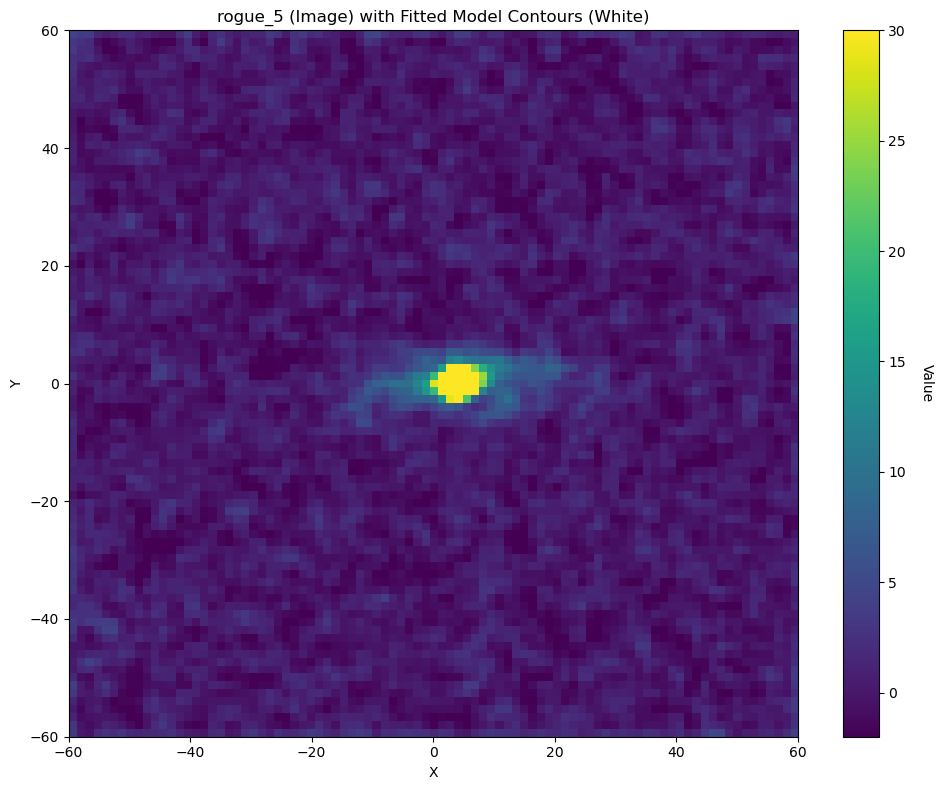

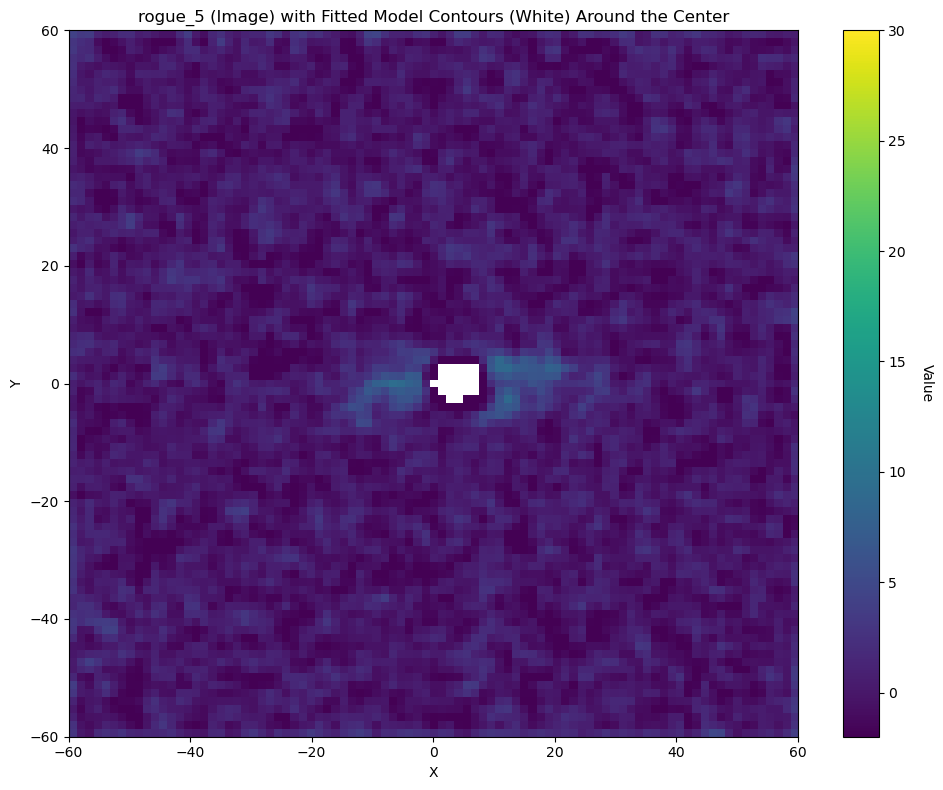

File name: mf_rogue_5_d=90.0_a=77.3_pix=8000.fits
Fitted Parameters:
A  = 1129.4515
h = 1.0089
q = 1.1858
x_offset = 3.7478
y_offset = 0.2515
theta = -7495012.3769
C  = 0.1412


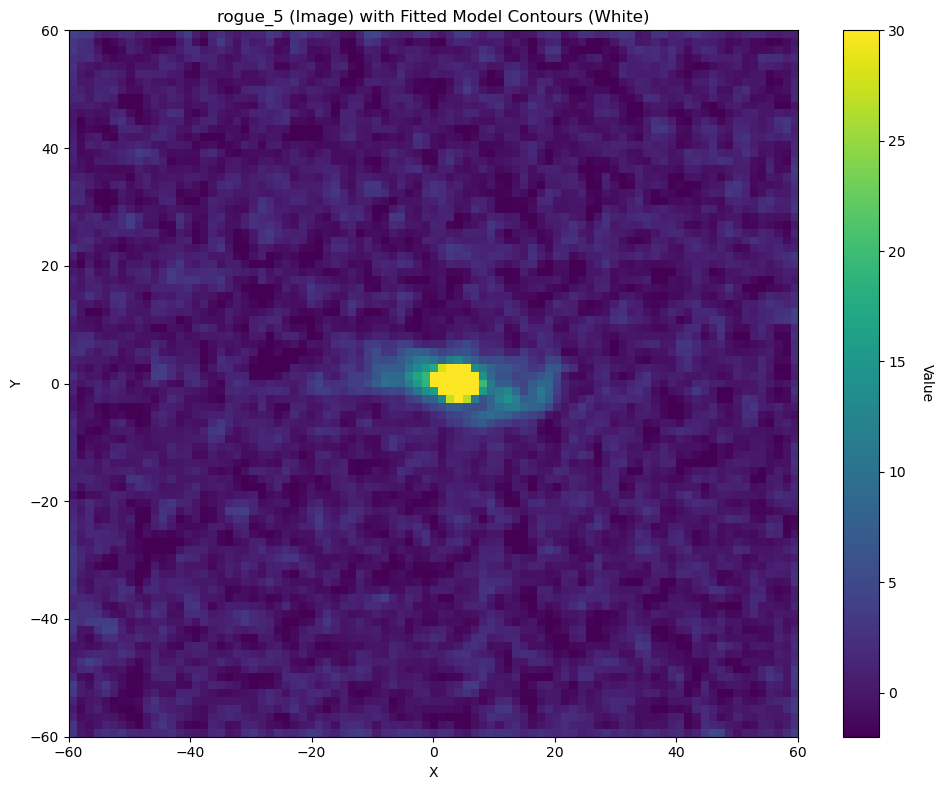

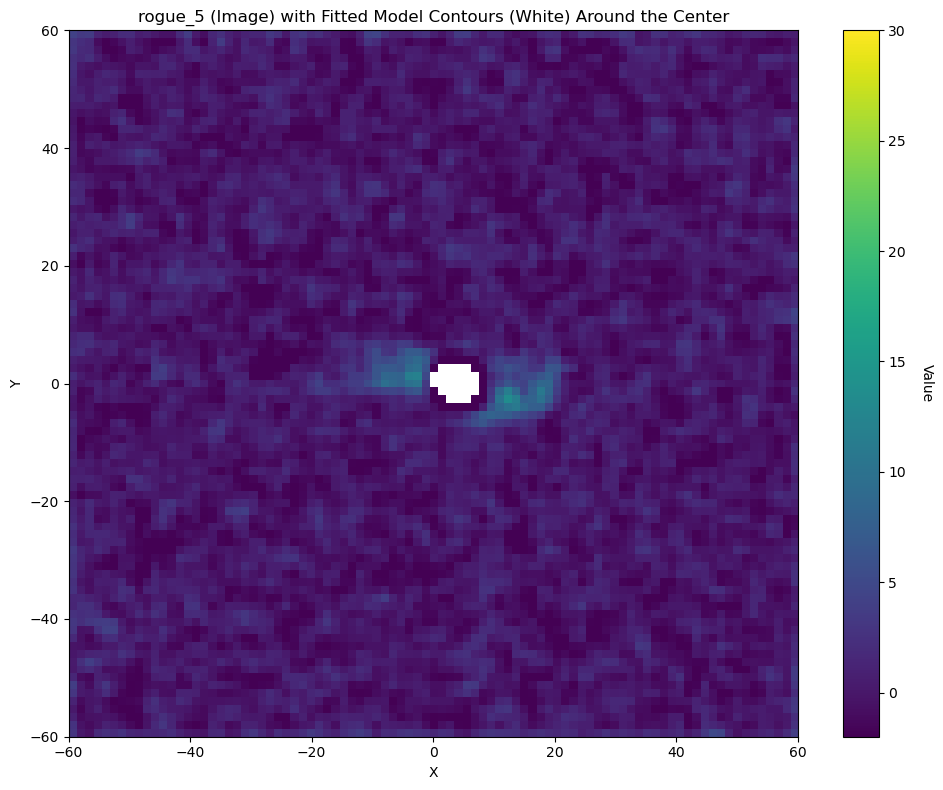

In [47]:
if os.path.exists(centers_path):
    os.remove(centers_path)

for file in sorted(mf_catalogs_path.iterdir()):
    if file.is_file():

        print(f'File name: {file.name}')

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        data=hdul[0].data

        # Generate synthetic mock data with noise
        x_line = np.linspace(-60, 60, 89)
        y_line = np.linspace(-60, 60, 89)
        X, Y = np.meshgrid(x_line, y_line)
        
        # Flatten the arrays to 1-D for curve_fit
        x_flat = X.ravel()
        y_flat = Y.ravel()
        z_flat = data.ravel()
        
        # Combine independent variables into an (2, N) shaped array
        independent_vars = np.vstack((x_flat, y_flat))
        
        # Perform the optimization
        fitted_params, covariance = curve_fit(
            f=exponential_2d, 
            xdata=independent_vars, 
            ydata=z_flat, 
            p0=initial_guess
        )

        Z_fitted = exponential_2d((X, Y), *fitted_params)

        z_fit_max = np.max(Z_fitted)
        mask_thresh = .05 * z_fit_max # Change thresh to what you want
        mask = Z_fitted < mask_thresh
        residual = data - Z_fitted
        masked_residual = residual.copy()
        masked_residual[~mask] = np.nan

        # Extract and view results
        A_fit, h_fit, q_fit, x_offset_fit, y_offset_fit, theta_fit, C_fit = fitted_params
        print("Fitted Parameters:")
        print(f"A  = {A_fit:.4f}")
        print(f"h = {h_fit:.4f}")
        print(f"q = {q_fit:.4f}")
        print(f"x_offset = {x_offset_fit:.4f}")
        print(f"y_offset = {y_offset_fit:.4f}")
        print(f"theta = {theta_fit:.4f}")
        print(f"C  = {C_fit:.4f}")

        with open(f'{centers_path}', 'a') as file:
            file.write('center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}' ':' f'{x_offset_fit:.4f}' ',' f'{y_offset_fit:.4f}' '\n')

        twod_exp_fit(d, a, inv_y = False)
        twod_exp_fit_res(d, a, inv_y = False)